# Task 4 — Library-prep disentanglement

**Question:** Can library-associated variation be separated from biological variation in frozen BridgeRNA representations?

This is a standalone benchmark motivated by Task 3. BridgeRNA is frozen, and NASA/OSDR data are never used for training, model selection, or hyperparameter tuning. Computation lives in `pipeline/`; this notebook reads saved outputs. We use *library-associated* unless controlled evidence supports a causal claim.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
HERE = Path.cwd()
if HERE.name != 'library_prep_disentanglement':
    candidate = HERE / 'benchmarks/library_prep_disentanglement'
    if candidate.exists(): HERE = candidate
RESULTS = HERE / 'results'
def read_csv(path): return pd.read_csv(path) if path.exists() else pd.DataFrame()
def read_json(path): return json.loads(path.read_text()) if path.exists() else {}
print('Benchmark:', HERE.resolve())

Benchmark: /home/walt/bridge-rna/benchmarks/library_prep_disentanglement


## 1. Data discovery and provenance

ARCHS4 labels are audited conservatively: `total RNA` alone is not treated as proof of rRNA depletion. True same-RNA pairs require authoritative deposited metadata.

In [2]:
audit = read_json(RESULTS/'task4a_data_audit/archs4_audit_summary.json')
display(pd.DataFrame([audit]).T.rename(columns={0:'value'}))
display(read_csv(RESULTS/'task4a_data_audit/archs4_explicit_label_summary.csv'))
display(read_csv(RESULTS/'task4a_data_audit/controlled_dataset_audit.csv'))

,value
metadata_rows,940455
explicitly_labeled_samples,180015
explicit_polya_samples,178770
explicit_ribo_samples,1201
conflicting_samples,44
studies_with_both_labels,31
verified_same_rna_pairs,0
classification,OBSERVATIONAL
reason,"Explicit labels exist, but ARCHS4 metadata do ..."


,library_label,species,samples,studies
0,conflict,human,28,2
1,conflict,mouse,16,2
2,polyA,human,91554,4018
3,polyA,mouse,87216,4150
4,ribo,human,768,76
5,ribo,mouse,433,45


,dataset,accession,species,tissue,n_pairs,same_rna,polyA_protocol,ribo_protocol,platform,role
0,Chen 2020 T cells,doi:10.1038/s41597-020-00719-4; syn22250947; f...,human,naive CD4+ T cells,40,yes,TruSeq RNA Library Prep v2,TruSeq Stranded Total RNA + Ribo-Zero Gold,Illumina paired-end,TRAIN
1,GSE150097 freeze-thaw,GSE150097 / SRP257988,human,blood leukocytes,pending authoritative pair map,candidate; verify pair IDs,TruSeq Stranded mRNA,TruSeq Stranded Total RNA + Ribo-Zero Gold,HiSeq 4000 (SE50 vs PE100 confounded),VALIDATION candidate
2,Zhao 2018 blood/colon,SRP127360,human,pooled blood; colon,2,yes; four technical libraries/arm,TruSeq Stranded mRNA,Globin-Zero blood; Ribo-Zero Gold colon,NextSeq 500 PE,TEST


The controlled 40-donor T-cell study is used for training. SRP127360 is completely held out, but contains only two biological source RNAs (pooled blood and colon), with four technical libraries per protocol. GSE150097 is retained as a candidate because its public records do not establish every cross-protocol pair. This exploratory run therefore uses fixed epochs without validation-driven selection.

## 2. Original frozen BridgeRNA baseline

,samples,datasets,verified_pairs,median_pair_cosine,mean_pair_cosine,pair_recall_at_1,pair_recall_at_5,pair_recall_at_10,pair_mrr,median_pair_rank,difference_pc1_variance,interpretation
0,96,2,42,0.9976,0.9920,0.1071,0.2976,0.5119,0.2228,9.5000,0.9631,"A dominant direction is descriptive, not evidence of a universal causal library effect."


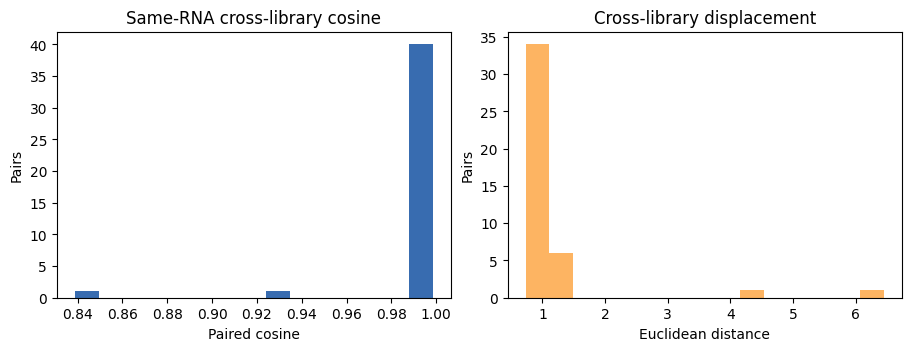

In [3]:
baseline = read_json(RESULTS/'task4c_bridge_baseline/summary.json')
display(pd.DataFrame([baseline]).style.format(precision=4))
pairs = read_csv(RESULTS/'task4c_bridge_baseline/bridge_pair_metrics.csv')
if len(pairs):
    fig, ax = plt.subplots(1, 2, figsize=(9, 3.4), layout='constrained')
    ax[0].hist(pairs.paired_cosine, bins=15, color='#386cb0')
    ax[0].set(xlabel='Paired cosine', ylabel='Pairs', title='Same-RNA cross-library cosine')
    ax[1].hist(pairs.euclidean_distance, bins=15, color='#fdb462')
    ax[1].set(xlabel='Euclidean distance', ylabel='Pairs', title='Cross-library displacement')
    plt.show()

High pair cosine does not guarantee donor retrieval. A dominant PolyA→Ribo difference component is evidence of reproducible displacement within a study, not proof of a universal causal library effect.

## 3. FE/RE decomposition and controls

,representation,auroc,balanced_accuracy,macro_f1,pairs,pair_cosine,pair_r1,pair_r5,pair_r10,pair_mrr,median_rank,biology_metric,biology_metric_value
0,Bridge,0.000,0.250,0.200,2,0.882,0.750,1.000,1.000,0.875,1.000,cross_library_source_identity_mrr,0.875
1,Linear baseline,0.500,0.500,0.333,2,0.883,0.750,1.000,1.000,0.875,1.000,cross_library_source_identity_mrr,0.875
2,FE,0.000,0.500,0.333,2,0.786,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
3,RE,0.000,0.250,0.200,2,0.165,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
4,FE without_pair,0.000,0.500,0.333,2,0.838,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
5,FE without_adversarial,0.078,0.250,0.200,2,0.996,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
6,FE shuffled_labels,0.000,0.000,0.000,2,1.000,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750
7,FE shuffled_pairs,0.000,0.500,0.333,2,0.986,0.500,1.000,1.000,0.750,1.500,cross_library_source_identity_mrr,0.750


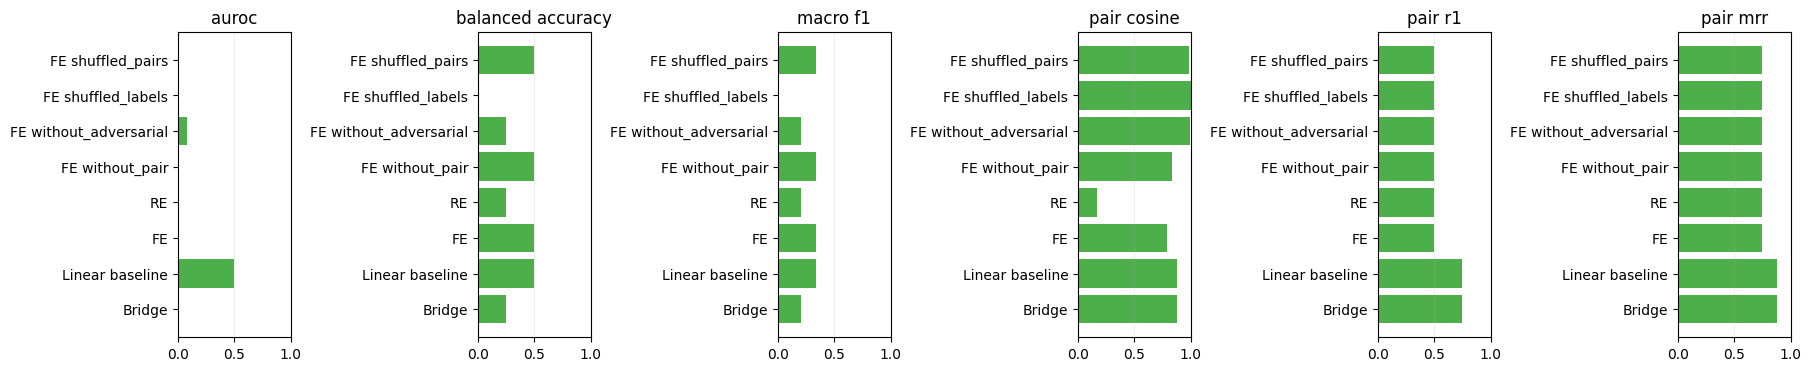

In [4]:
summary = read_csv(RESULTS/'task4_disentanglement/main_summary.csv')
if summary.empty:
    display(Markdown('*Disentanglement results are not available yet.*'))
else:
    display(summary.style.format(precision=3, na_rep='—'))
    metrics = [c for c in ['auroc','balanced_accuracy','macro_f1','pair_cosine','pair_r1','pair_mrr'] if c in summary]
    fig, axes = plt.subplots(1, len(metrics), figsize=(3*len(metrics), 3.6), layout='constrained')
    for ax, column in zip(np.atleast_1d(axes), metrics):
        ax.barh(summary.representation, summary[column], color='#4daf4a')
        ax.set(title=column.replace('_',' '), xlim=(0,1)); ax.grid(axis='x', alpha=.2)
    plt.show()

FE is successful only if held-out library prediction falls while cross-library biological identity improves. RE should retain library-associated information. Linear removal, loss ablations, and shuffled controls test whether the neural decomposition adds value.

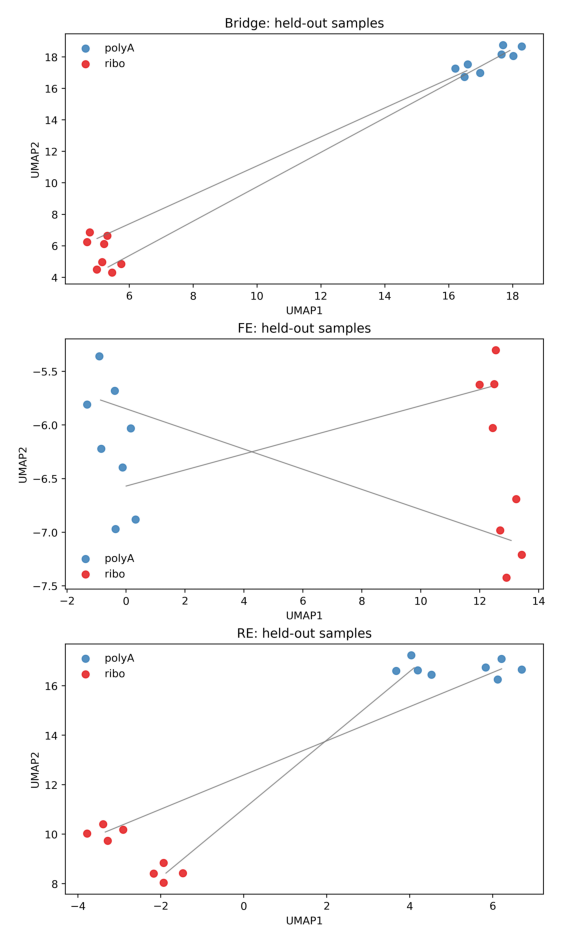

In [5]:
umap_png = RESULTS/'task4_disentanglement/heldout_representation_umaps.png'
if umap_png.exists():
    image = plt.imread(umap_png)
    plt.figure(figsize=(8,12)); plt.imshow(image); plt.axis('off'); plt.show()

## 4. Independent Task 3 challenge

,representation,comparison,left,right,cosine,spearman,left_norm,right_norm
0,Bridge,RR1,RR1_OSD48_original_matched,RR1_OSD168_no-ERCC,-0.804,-0.170,0.932,0.485
1,Bridge,RR1 ERCC,RR1_OSD48_original_matched,RR1_OSD168_all_ERCC,-0.808,-0.163,0.932,0.507
2,Bridge,RR3-39,C01_OSD137_original_matched,C01_OSD168_all_ERCC,0.790,0.509,0.235,0.191
3,Bridge,RR3-40,C02_OSD137_original_matched,C02_OSD168_all_ERCC,0.917,0.878,0.149,0.179
4,Bridge,ERCC/no-ERCC,RR1_OSD168_no-ERCC,RR1_OSD168_all_ERCC,0.998,0.993,0.485,0.507
5,Linear baseline,RR1,RR1_OSD48_original_matched,RR1_OSD168_no-ERCC,-0.709,-0.591,0.607,0.404
6,Linear baseline,RR1 ERCC,RR1_OSD48_original_matched,RR1_OSD168_all_ERCC,-0.708,-0.586,0.607,0.419
7,Linear baseline,RR3-39,C01_OSD137_original_matched,C01_OSD168_all_ERCC,0.724,0.637,0.193,0.170
8,Linear baseline,RR3-40,C02_OSD137_original_matched,C02_OSD168_all_ERCC,0.881,0.866,0.124,0.136
9,Linear baseline,ERCC/no-ERCC,RR1_OSD168_no-ERCC,RR1_OSD168_all_ERCC,0.997,0.996,0.404,0.419


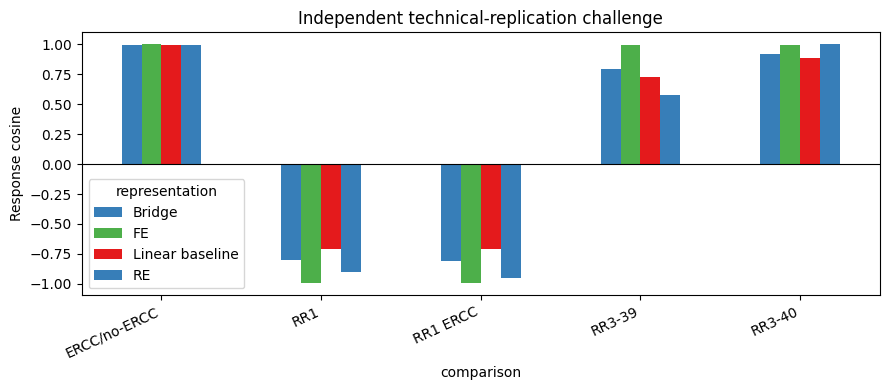

In [6]:
task3 = read_csv(RESULTS/'task4g_task3_challenge/task3_challenge_metrics.csv')
if task3.empty:
    display(Markdown('*Independent Task 3 application is not available yet.*'))
else:
    display(task3.style.format(precision=3))
    pivot = task3.pivot(index='comparison', columns='representation', values='cosine')
    ax = pivot.plot.bar(figsize=(9,4), color=['#377eb8','#4daf4a','#e41a1c'])
    ax.axhline(0,color='black',lw=.8); ax.set(ylabel='Response cosine', title='Independent technical-replication challenge')
    plt.xticks(rotation=25,ha='right'); plt.tight_layout(); plt.show()

Task 3 is an external challenge, not a tuning set. RR1 improvement matters only if RR3 and ERCC/no-ERCC relationships remain robust; changing the RR1 sign alone is not success.

## 5. Does RR1 align with a controlled PolyA→Ribo subspace?

This diagnostic uses only the **original frozen BridgeRNA embeddings**. The technical direction and SVD basis are learned from 40 verified same-RNA T-cell pairs; OSDR is used only afterward as an external diagnostic. Difference vectors are consistently defined as `Ribo − PolyA` or `OSD-168 new/Ribo-like − OSD-48 old/PolyA-like`.

The removal basis is the uncentered SVD of donor-wise differences, which retains their shared mean displacement. Centered PCA variance is also saved. This is a mechanism check—not a recommended correction.

,metric,result
0,Median controlled PolyA/Ribo pair cosine,0.9976
1,Median cosine among d_i,0.9802
2,Mean LOO technical-direction cosine,0.9860
3,LOO mismatched-null empirical p,0.0010
4,Uncentered PC1 variance explained,0.9747
5,Uncentered PC1-5 cumulative variance,0.9952
6,Independent blood alignment,-0.6572
7,Independent colon alignment,-0.7612
8,RR1 sample displacement median cosine with d_library,0.7885
9,RR1 sample displacement median variance captured PC1,0.6410


,metric,n,mean,median,sd,q25,q75,iqr
0,difference_norm,40,0.9644,0.9200,0.1698,0.8386,1.0597,0.2211
1,paired_embedding_cosine,40,0.9975,0.9976,0.0007,0.9971,0.9980,0.0009
2,pairwise_difference_cosine,780,0.9732,0.9802,0.0224,0.9675,0.9876,0.0200
3,loo_direction_cosine,40,0.9860,0.9895,0.0130,0.9860,0.9935,0.0075
4,loo_ribo_minus_polyA_projection,40,0.9512,0.9151,0.1678,0.8285,1.0516,0.2231


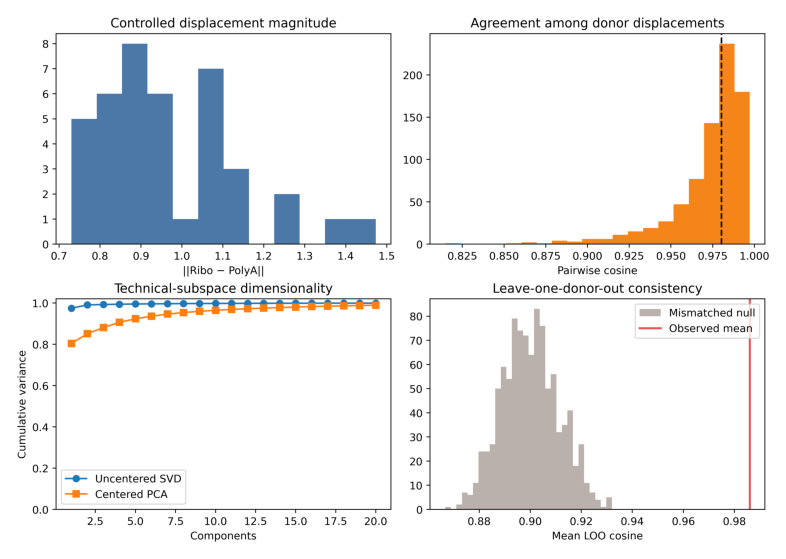

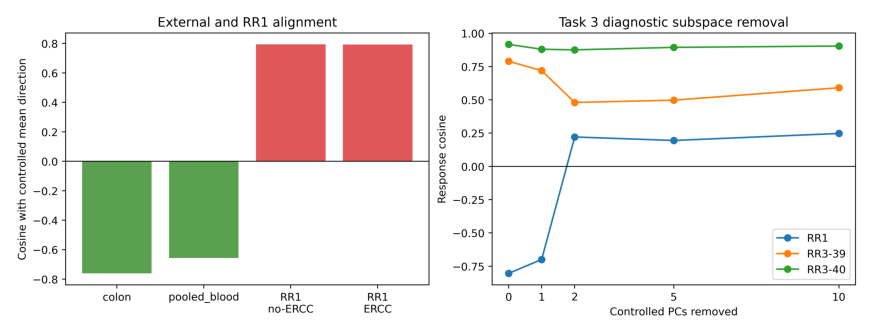

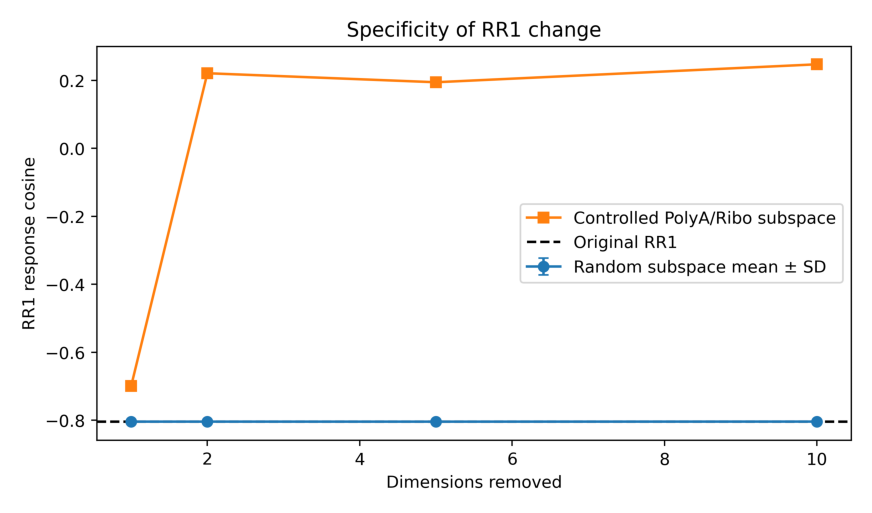

In [7]:
follow = RESULTS/'task4_followup_controlled_subspace'
diagnostic = read_csv(follow/'concise_summary.csv')
display(diagnostic.style.format({'result':'{:.4f}'}))
dist = read_csv(follow/'controlled_distribution_summary.csv')
display(dist.style.format(precision=4))
for name in ['controlled_library_geometry.png','external_rr1_alignment_and_removal.png','random_subspace_control.png']:
    path = follow/name
    if path.exists():
        img = plt.imread(path); plt.figure(figsize=(11,7)); plt.imshow(img); plt.axis('off'); plt.show()

### External orientation, correction specificity, and biological damage

An RR1 sign change is not sufficient evidence. We compare learned removal with 500 deterministic random subspaces per dimension and quantify how much original geometry, neighborhood structure, controlled pair retrieval, and RR3 technical preservation remain.

In [8]:
display(read_csv(follow/'independent_source_alignment.csv').style.format(precision=4))
display(read_csv(follow/'task3_response_after_subspace_removal.csv').style.format(precision=4))
display(read_csv(follow/'controlled_geometry_damage.csv').style.format(precision=4))
display(read_csv(follow/'random_subspace_rr1_summary.csv').style.format(precision=4))

,source,difference_norm,cosine_with_tcell_mean,fraction_magnitude_squared_in_pc1_1,fraction_magnitude_squared_in_pc1_2,fraction_magnitude_squared_in_pc1_5,fraction_magnitude_squared_in_pc1_10
0,colon,4.2291,-0.7612,0.5993,0.9689,0.9714,0.9796
1,pooled_blood,6.4471,-0.6572,0.4484,0.7842,0.8533,0.9172


,comparison,removed_components,cosine,spearman,norm_a,norm_b
0,RR1,0,-0.8041,-0.1702,0.9317,0.4853
1,RR1_ERCC,0,-0.8084,-0.1626,0.9317,0.5069
2,RR3-39,0,0.7900,0.5087,0.2347,0.1913
3,RR3-40,0,0.9166,0.8783,0.1486,0.1790
4,ERCC/no-ERCC,0,0.9981,0.9928,0.4853,0.5069
5,RR1,1,-0.6994,-0.5881,0.5935,0.3997
6,RR1_ERCC,1,-0.6985,-0.5822,0.5935,0.4139
7,RR3-39,1,0.7194,0.6354,0.1907,0.1688
8,RR3-40,1,0.8801,0.8657,0.1235,0.1347
9,ERCC/no-ERCC,1,0.9972,0.9961,0.3997,0.4139


,removed_components,mean_original_corrected_cosine,median_original_corrected_cosine,mean_top10_neighbor_overlap,variance_removed_fraction,median_pair_cosine,pair_r1,pair_r5,pair_r10,pair_mrr,median_rank
0,1,0.7743,0.7700,0.4700,0.4021,0.9999,0.8500,0.9250,0.9500,0.8878,1.0000
1,2,0.6724,0.6700,0.3212,0.5493,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000
2,5,0.6604,0.6589,0.3137,0.5653,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,10,0.6309,0.6311,0.3137,0.6033,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


,removed_components,mean,median,std,min,max,learned_rr1_cosine,fraction_random_at_least_as_improved
0,1,-0.8041,-0.8041,0.0007,-0.8082,-0.8011,-0.6994,0.0000
1,2,-0.8041,-0.8042,0.0009,-0.8074,-0.7995,0.2210,0.0000
2,5,-0.8042,-0.8042,0.0016,-0.8086,-0.7984,0.1945,0.0000
3,10,-0.8040,-0.8040,0.0022,-0.8106,-0.7954,0.2473,0.0000


The controlled T-cell effect is strongly reproducible *within that study*, and individual RR1 old→new displacements substantially project into the T-cell basis. However, held-out pooled blood and colon point in the opposite orientation. Five-component removal changes RR1 strongly and much more than random removal, but also removes a large fraction of embedding energy, disrupts neighborhoods, and weakens RR3-39. Therefore this supports **partial, context-dependent overlap**, not a universal PolyA/Ribo direction or a validated correction. The next correction effort should model the broader protocol transition and acquire additional independent same-RNA studies rather than treating library selection alone as established causality.

## 6. Held-out response-geometry robustness

The following analysis removes the independently learned T-cell technical basis from **individual OSDR sample embeddings before** reconstructing each fixed `FLT − GC` response. No OSDR result affects the basis. Original sample memberships, technical-replication mappings, 14 response vectors, ordering, and mode labels are unchanged.

The primary preservation evidence is response-level—not global sample neighborhoods. Results are shown for 0, 1, 2, 3, 5, and 10 removed dimensions, with 500 deterministic random orthonormal controls per nonzero dimension.

,comparison,recomputed_cosine,saved_cosine,absolute_difference,verified
0,RR1 noERCC,-0.804119,-0.804119,0.000000,True
1,RR1 allERCC,-0.808434,-0.808434,0.000000,True
2,RR3-39,0.790004,0.790003,0.000000,True
3,RR3-40,0.916648,0.916649,0.000000,True


,comparison,0,1,2,3,5,10
0,OSD168 noERCC/allERCC,0.998,0.997,0.991,0.992,0.992,0.992
1,RR1 allERCC,-0.808,-0.699,0.241,0.212,0.204,0.249
2,RR1 noERCC,-0.804,-0.699,0.221,0.198,0.195,0.247
3,RR3-39,0.790,0.719,0.480,0.509,0.497,0.591
4,RR3-40,0.917,0.880,0.876,0.879,0.894,0.904


,comparison,0,1,2,3,5,10
0,OSD168 noERCC/allERCC,0.993,0.996,0.991,0.991,0.991,0.991
1,RR1 allERCC,-0.163,-0.582,0.226,0.188,0.186,0.235
2,RR1 noERCC,-0.170,-0.588,0.203,0.173,0.173,0.232
3,RR3-39,0.509,0.635,0.447,0.483,0.476,0.574
4,RR3-40,0.878,0.866,0.869,0.871,0.889,0.900


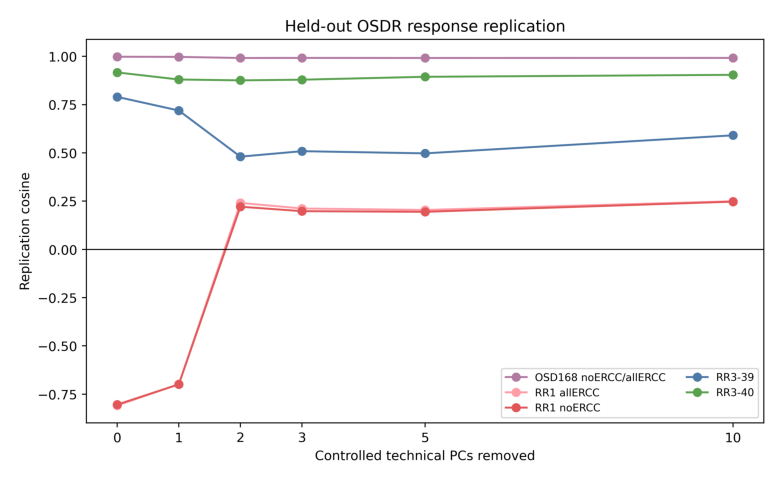

In [9]:
robust = RESULTS/'task4_response_robustness'
verify = read_csv(robust/'original_metric_verification.csv')
display(verify.style.format(precision=6))
display(read_csv(robust/'technical_replication_cosine_curve.csv').style.format(precision=3))
display(read_csv(robust/'technical_replication_spearman_curve.csv').style.format(precision=3))
img=plt.imread(robust/'figure_a_replication_curve.png');plt.figure(figsize=(11,6));plt.imshow(img);plt.axis('off');plt.show()

### Response damage and fixed-mode preservation

For an orthogonal projection, `cos(Δz_original, Δz_corrected)` equals the retained norm fraction; both are retained in the raw table for clarity. Mode assignments are never refit. ARI compares unsupervised two-cluster structure with the original fixed labels.

,removed_components,contrast_group,contrasts,response_cosine_mean,response_cosine_median,response_cosine_sd,norm_ratio_mean,norm_ratio_median,norm_ratio_sd
0,0,RR1,3,1.000,1.000,0.000,1.000,1.000,0.000
1,0,RR3,5,1.000,1.000,0.000,1.000,1.000,0.000
2,0,other,6,1.000,1.000,0.000,1.000,1.000,0.000
3,1,RR1,3,0.756,0.764,0.108,0.756,0.764,0.108
4,1,RR3,5,0.812,0.813,0.061,0.812,0.813,0.061
5,1,other,6,0.829,0.796,0.127,0.829,0.796,0.127
6,2,RR1,3,0.416,0.337,0.217,0.416,0.337,0.217
7,2,RR3,5,0.566,0.557,0.064,0.566,0.557,0.064
8,2,other,6,0.638,0.577,0.251,0.638,0.577,0.251
9,3,RR1,3,0.414,0.335,0.218,0.414,0.335,0.218


,removed_components,same_mode_mean,same_mode_median,different_mode_mean,different_mode_median,same_minus_different_mean,silhouette_cosine_fixed_labels,cluster_ARI_vs_original_labels,matrix_spearman_vs_original,matrix_pearson_vs_original
0,0,0.638,0.737,-0.624,-0.705,1.261,0.763,1.000,1.000,1.000
1,1,0.525,0.604,-0.509,-0.572,1.034,0.666,1.000,0.988,0.989
2,2,0.141,0.171,-0.139,-0.148,0.280,0.225,0.272,0.619,0.560
3,3,0.149,0.163,-0.142,-0.161,0.290,0.233,0.272,0.611,0.562
4,5,0.128,0.111,-0.119,-0.131,0.247,0.200,0.116,0.559,0.511
5,10,0.130,0.058,-0.124,-0.137,0.255,0.204,0.116,0.576,0.527


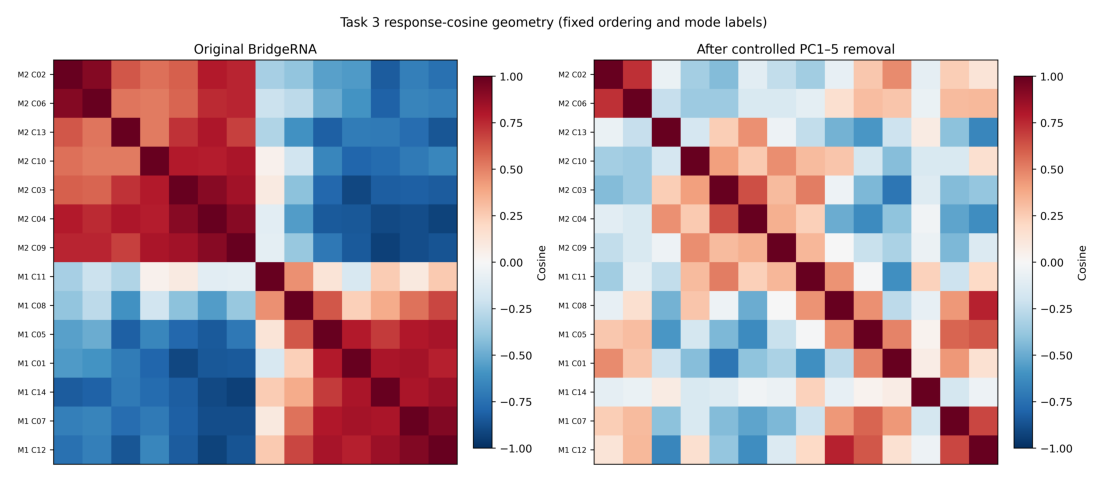

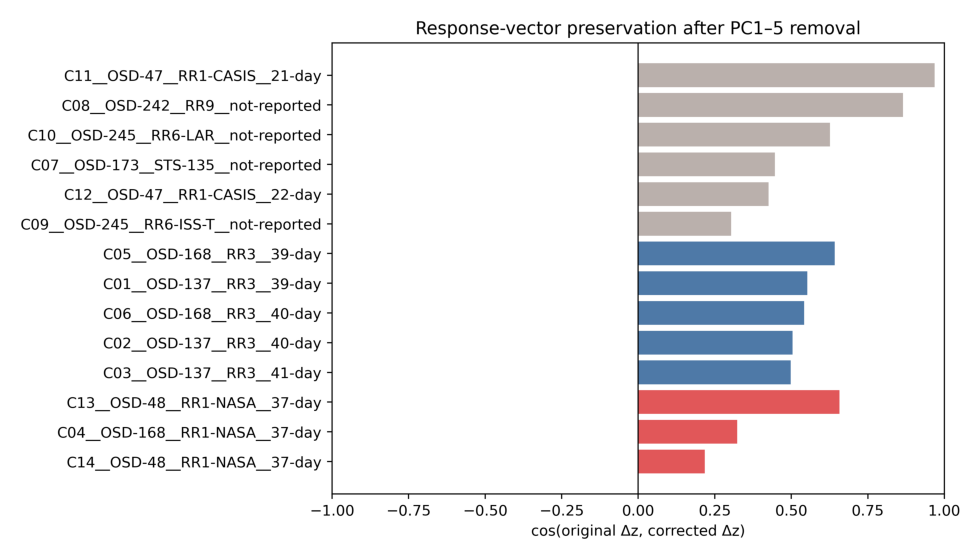

In [10]:
display(read_csv(robust/'response_damage_summary.csv').style.format(precision=3))
display(read_csv(robust/'task3_mode_preservation.csv').style.format(precision=3))
for name in ['figure_b_response_matrices.png','figure_c_response_preservation.png']:
    img=plt.imread(robust/name);plt.figure(figsize=(14,7));plt.imshow(img);plt.axis('off');plt.show()

### Selectivity and absolute-space versus response-space geometry

The controlled basis is compared with at least 500 random bases at every dimension. A selective RR1 change is informative mechanistically, but it is not sufficient if RR3 or the broader response organization is damaged.

,removed_components,metric,controlled_value,random_mean,random_sd,empirical_percentile,one_sided_p_random_at_least_as_high
0,1,rr1_cosine,-0.6994,-0.8041,0.0007,1.0000,0.0020
1,1,rr3_39_cosine,0.7194,0.7900,0.0007,0.0000,1.0000
2,1,rr3_40_cosine,0.8801,0.9166,0.0003,0.0000,1.0000
3,1,same_minus_different_mean,1.0338,1.2615,0.0011,0.0000,1.0000
4,1,matrix_spearman_vs_original,0.9881,1.0000,0.0000,0.0000,1.0000
5,2,rr1_cosine,0.2210,-0.8041,0.0010,1.0000,0.0020
6,2,rr3_39_cosine,0.4804,0.7900,0.0010,0.0000,1.0000
7,2,rr3_40_cosine,0.8756,0.9167,0.0004,0.0000,1.0000
8,2,same_minus_different_mean,0.2797,1.2615,0.0017,0.0000,1.0000
9,2,matrix_spearman_vs_original,0.6188,1.0000,0.0000,0.0000,1.0000


,metric,result
0,RR1 cosine original,-0.8041
1,RR1 cosine PC1-5 removed,0.1945
2,RR3-39 cosine original,0.7900
3,RR3-39 cosine PC1-5 removed,0.4974
4,RR3-40 cosine original,0.9166
5,RR3-40 cosine PC1-5 removed,0.8941
6,Median response-vector preservation PC1-5,0.5232
7,Median response norm ratio PC1-5,0.5232
8,Response-matrix Spearman preservation PC1-5,0.5592
9,Mode silhouette original,0.7630


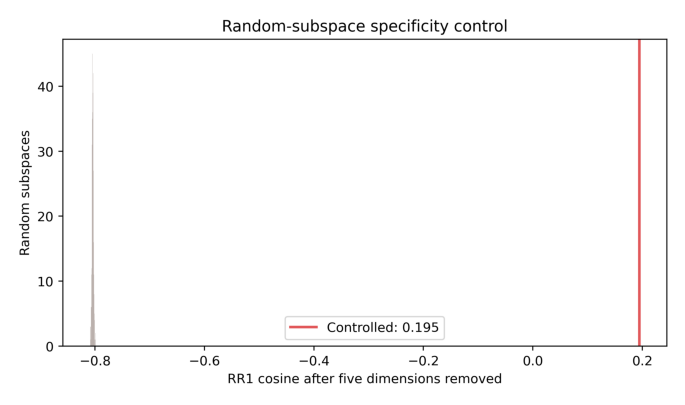

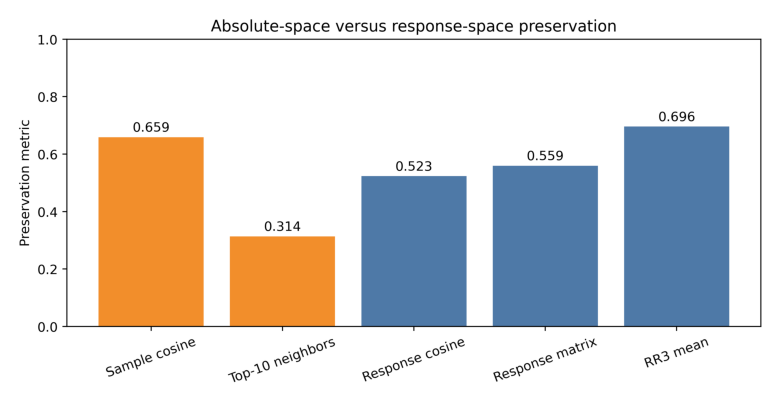

In [11]:
display(read_csv(robust/'random_subspace_summary.csv').style.format(precision=4))
display(read_csv(robust/'concise_summary.csv').style.format({'result':'{:.4f}'}))
for name in ['figure_d_rr1_random_null.png','figure_e_absolute_vs_response.png']:
    img=plt.imread(robust/name);plt.figure(figsize=(10,5));plt.imshow(img);plt.axis('off');plt.show()

### Response-robustness conclusion

1. **RR1:** The independently learned basis explains a specific component of the RR1 reversal: PC1–5 removal changes cosine from about −0.804 to +0.195, beyond all 500 matched random removals.
2. **RR3:** Preservation is mixed. RR3-40 remains high, whereas RR3-39 falls materially.
3. **Broader Task 3 geometry:** It is not preserved well after five components. The response-matrix correlation falls to roughly 0.56, fixed-label silhouette drops sharply, and unsupervised agreement with the original modes is low.
4. **Response versus absolute geometry:** Median response preservation is somewhat lower than median absolute sample cosine, though it exceeds Top-10 neighborhood overlap. These results do not show that response geometry is generally immune to the removal.
5. **Usefulness of Δz:** Uncorrected within-study response vectors remain valuable for controlled cross-study technical comparisons, but this particular removal trades a selective RR1 improvement against substantial global response reorganization.
6. **Purified biology:** **No.** We have identified and removed a controlled, technical-associated subspace; neither the residual nor its positive RR1 cosine can be called pure spaceflight biology.

## 7. Gene-level basis of RR1 instability

Signed Integrated Gradients are computed independently for the six fixed response measurements using the established zero-expression baseline and frozen BridgeRNA encoder. Within each technical pair, the **original OSD-48 or OSD-137 Δz direction is held fixed** for both measurements. This is essential: orienting each response toward itself would conceal reversal. The controlled signature is independently defined as `IG(mean T-cell Ribo) − IG(mean T-cell PolyA)` along the controlled mean latent displacement.

Genes are ranked by absolute attribution while retaining sign. The tables below verify the latent responses and compare Top-100 overlap, random-overlap enrichment, genome-wide signed Spearman correlation, union-Top-100 correlation, and sign agreement.

,comparison,original_response,remeasurement_response,original_norm,remeasurement_norm,recomputed_cosine,saved_cosine,absolute_difference,verified
0,RR1,RR1_OSD48_original_matched,RR1_OSD168_no-ERCC,0.931650,0.485264,-0.804119,-0.804119,0.000000,True
1,RR3-39,C01_OSD137_original_matched,C01_OSD168_all_ERCC,0.234695,0.191301,0.790003,0.790003,0.000000,True
2,RR3-40,C02_OSD137_original_matched,C02_OSD168_all_ERCC,0.148579,0.178983,0.916649,0.916649,0.000000,True


,top_n,shared,jaccard,expected_random_overlap,overlap_enrichment,hypergeom_p,same_sign_fraction,opposite_sign_fraction,comparison,full_signed_spearman,top100_union_signed_spearman
0,100,53,0.3605,0.6594,80.3745,0.0000,0.9623,0.0377,RR1,0.1938,0.6547
1,100,71,0.5504,0.6594,107.6715,0.0000,0.9859,0.0141,RR3-39,0.6012,0.8297
2,100,76,0.6129,0.6594,115.2540,0.0000,1.0000,0.0000,RR3-40,0.5972,0.8736


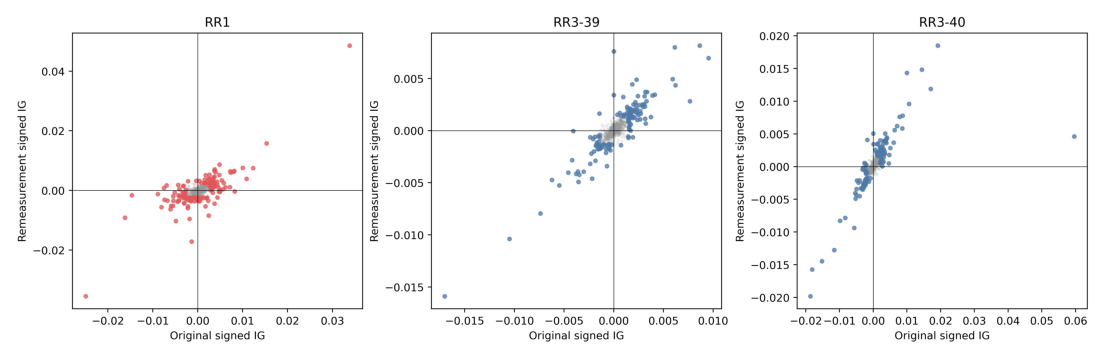

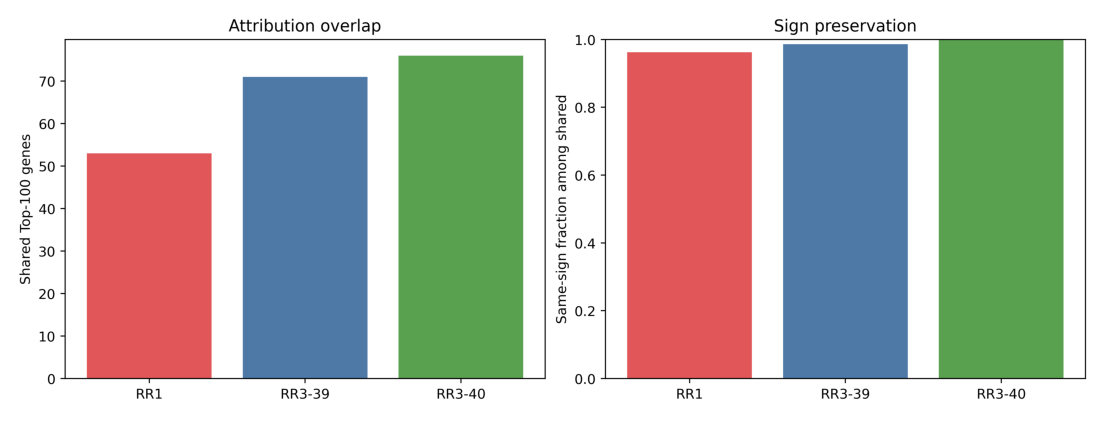

In [12]:
gene_diag=RESULTS/'task4_gene_attribution_diagnostic'
display(read_csv(gene_diag/'latent_response_verification.csv').style.format(precision=6))
ig_compare=read_csv(gene_diag/'technical_replication_ig_comparison.csv')
display(ig_compare.style.format(precision=4))
for name in ['figure_a_signed_attribution_scatter.png','figure_b_top100_overlap_sign.png']:
    img=plt.imread(gene_diag/name);plt.figure(figsize=(14,6));plt.imshow(img);plt.axis('off');plt.show()

### Controlled technical signature and expression-level control

The controlled PolyA→Ribo signature is compared with `remeasurement attribution − original attribution` at Top-100, Top-250, and Top-500. These cutoff analyses are sensitivity checks, not independent tests. Conventional expression uses the identical samples and 15,165-gene `log1p(TPM)` inputs.

,top_n,shared,jaccard,expected_random_overlap,overlap_enrichment,hypergeom_p,same_sign_fraction,opposite_sign_fraction,comparison,signature
0,100,11,0.0582,0.6594,16.6815,0.0000,0.4545,0.5455,RR1,controlled_vs_remeasurement_minus_original
1,250,49,0.1086,4.1213,11.8894,0.0000,0.4490,0.5510,RR1,controlled_vs_remeasurement_minus_original
2,500,125,0.1429,16.4853,7.5825,0.0000,0.4560,0.5440,RR1,controlled_vs_remeasurement_minus_original
3,100,10,0.0526,0.6594,15.1650,0.0000,0.5000,0.5000,RR3-39,controlled_vs_remeasurement_minus_original
4,250,37,0.0799,4.1213,8.9777,0.0000,0.5676,0.4324,RR3-39,controlled_vs_remeasurement_minus_original
5,500,94,0.1038,16.4853,5.7020,0.0000,0.5851,0.4149,RR3-39,controlled_vs_remeasurement_minus_original
6,100,9,0.0471,0.6594,13.6485,0.0000,0.5556,0.4444,RR3-40,controlled_vs_remeasurement_minus_original
7,250,39,0.0846,4.1213,9.4630,0.0000,0.4359,0.5641,RR3-40,controlled_vs_remeasurement_minus_original
8,500,100,0.1111,16.4853,6.0660,0.0000,0.5100,0.4900,RR3-40,controlled_vs_remeasurement_minus_original


,top_n,shared,jaccard,expected_random_overlap,overlap_enrichment,hypergeom_p,same_sign_fraction,opposite_sign_fraction,comparison,full_gene_cosine,full_gene_spearman
0,100,46,0.2987,0.6594,69.7590,0.0000,1.0000,0.0000,RR1,0.3692,0.4248
1,100,58,0.4085,0.6594,87.9570,0.0000,1.0000,0.0000,RR3-39,0.6523,0.6183
2,100,87,0.7699,0.6594,131.9355,0.0000,1.0000,0.0000,RR3-40,0.8224,0.6730


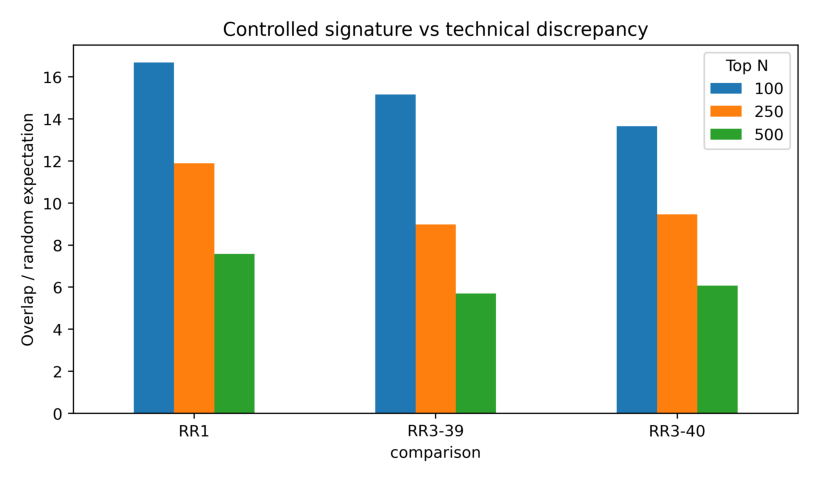

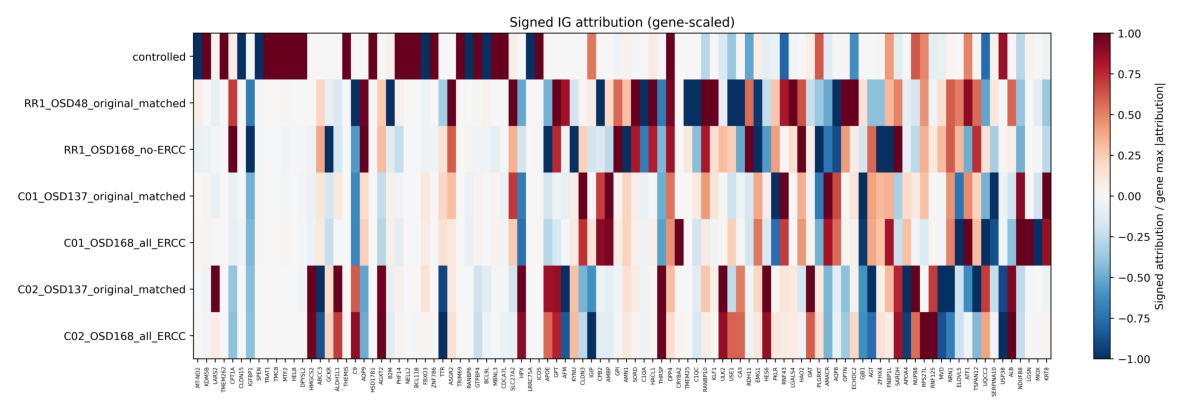

In [13]:
display(read_csv(gene_diag/'controlled_signature_discrepancy_overlap.csv').style.format(precision=4))
display(read_csv(gene_diag/'expression_response_comparison.csv').style.format(precision=4))
for name in ['figure_c_controlled_signature_overlap.png','figure_d_signed_gene_heatmap.png']:
    img=plt.imread(gene_diag/name);plt.figure(figsize=(15,6));plt.imshow(img);plt.axis('off');plt.show()

### Gene-set interpretation

GO Biological Process, KEGG, and Reactome enrichment uses the exact 15,165-gene model vocabulary as custom background with g:Profiler multiple-testing correction. Empty gene-set/source combinations mean no significant terms, not missing computation. Attribution is associative and is not evidence that a gene causes technical sensitivity.

In [14]:
enrichment=read_csv(gene_diag/'enrichment.csv')
if len(enrichment):
    cols=[c for c in ['query','source','native','name','p_value','intersection_size'] if c in enrichment]
    display(enrichment.sort_values('p_value').groupby('query',group_keys=False).head(12)[cols].style.format({'p_value':'{:.2e}'}))
display(read_csv(gene_diag/'interpretation_gene_sets.csv').groupby('gene_set').size().rename('genes').to_frame())

,query,source,native,name,p_value,intersection_size
0,RR3_reproducible,REAC,REAC:R-HSA-1430728,Metabolism,9.23e-12,48
1,RR3_reproducible,GO:BP,GO:0044281,small molecule metabolic process,5.17e-10,43
2,RR3_reproducible,GO:BP,GO:0043436,oxoacid metabolic process,9.55e-09,30
3,RR3_reproducible,GO:BP,GO:0006082,organic acid metabolic process,1.21e-08,30
4,RR3_reproducible,GO:BP,GO:0019752,carboxylic acid metabolic process,3.36e-08,29
5,RR1_shared_same_sign,GO:BP,GO:0044282,small molecule catabolic process,8.33e-07,13
6,RR1_shared_same_sign,GO:BP,GO:0044281,small molecule metabolic process,2.45e-06,23
7,RR1_shared_same_sign,KEGG,KEGG:01200,Carbon metabolism,3.41e-06,7
8,RR1_shared_same_sign,KEGG,KEGG:04976,Bile secretion,4.81e-06,6
9,RR1_shared_same_sign,REAC,REAC:R-HSA-1430728,Metabolism,1.19e-05,22


,genes
gene_set,
RR1_original_specific,47
RR1_remeasurement_specific,47
RR1_shared_opposite_sign,2
RR1_shared_same_sign,51
RR3_reproducible,123
controlled_and_RR1_discrepancy,11
controlled_polyA_ribo_top100,100


### Gene-level conclusion

1. **RR1 is a mixture, dominated by attribution reweighting rather than simple sign reversal.** It retains 53 shared Top-100 genes, 96.2% with the same sign, but genome-wide signed Spearman is only 0.194. Its reversed latent vector therefore arises from broad changes in attribution magnitude and the remaining gene set, not wholesale reversal of the shared leading genes.
2. **RR3 is more reproducible.** RR3-39 and RR3-40 share 71 and 76 Top-100 genes, with genome-wide signed Spearman around 0.60 and nearly complete sign preservation.
3. **Controlled-signature overlap is statistically enriched but only modestly preferential for RR1.** RR1 shares 11/49/125 genes at Top-100/250/500 versus 10/37/94 for RR3-39 and 9/39/100 for RR3-40. This supports partial overlap, not a uniquely PolyA/Ribo-driven RR1 mechanism.
4. **Expression already contains the instability.** RR1 expression cosine is 0.369, below RR3-39 (0.652) and RR3-40 (0.822). BridgeRNA reorganizes and accentuates an existing expression-level discrepancy.
5. **Biology:** Shared RR1 genes and reproducible RR3 genes both emphasize hepatic small-molecule, organic-acid, lipid, bile-secretion, and broader metabolic programs. No significant coherent enrichment was detected for the two opposite-sign RR1 genes, measurement-specific sets, controlled Top-100 signature, or the 11-gene controlled/RR1 intersection.

The technically unstable RR1 response has an interpretable gene-level signature, but these results neither identify causal “batch genes” nor isolate pure biological signal.

## 8. Are simple corrections better than controlled SVD projection?

All linear corrections are learned solely from the 40 paired T-cell donors. Controlled-pair evaluation uses leave-one-donor-out fitting and testing. OSDR remains fully held out. The comparison includes no correction, mean-direction projection, SVD PC1–1/2/3/5, paired additive residualization, and the already trained FE representation.

`library_auroc` retains the signed held-donor result. An AUROC near zero represents systematic inversion, not proof that library information vanished; `library_orientation_free_auroc` and `library_accuracy_chance_proximity` make that distinction explicit. FE Euclidean distances and original-versus-corrected vector cosines are not comparable across its 64-D coordinate system and the original 512-D space.

In [15]:
simple=RESULTS/'task4_simple_correction_comparison'
trade=read_csv(simple/'correction_tradeoff_summary.csv')
show=['method','paired_cosine','paired_euclidean','pair_r1','library_auroc','library_orientation_free_auroc','library_accuracy_chance_proximity','RR1','RR3-39','RR3-40','response_matrix_preservation','median_response_preservation','mode_ARI','mode_silhouette','sample_cosine_preservation','top10_neighbor_overlap']
display(trade[[c for c in show if c in trade]].style.format(precision=3,na_rep='—'))
display(read_csv(simple/'svd_correction_curve.csv').style.format(precision=3))

,method,paired_cosine,paired_euclidean,pair_r1,library_auroc,library_orientation_free_auroc,library_accuracy_chance_proximity,RR1,RR3-39,RR3-40,response_matrix_preservation,median_response_preservation,mode_ARI,mode_silhouette,sample_cosine_preservation,top10_neighbor_overlap
0,none,0.998,0.920,0.100,1.000,1.000,0.000,-0.804,0.790,0.917,1.000,1.000,1.000,0.763,1.000,1.000
1,mean_direction_projection,1.000,0.133,0.825,0.000,1.000,0.000,-0.709,0.724,0.881,0.989,0.799,1.000,0.673,0.724,0.930
2,svd_pc1_1,1.000,0.139,0.812,0.000,1.000,0.000,-0.699,0.719,0.880,0.988,0.788,1.000,0.666,0.714,0.929
3,svd_pc1_2,1.000,0.091,0.988,0.202,0.798,0.650,0.221,0.480,0.876,0.619,0.541,0.272,0.225,0.555,0.758
4,svd_pc1_3,1.000,0.087,1.000,0.247,0.753,0.625,0.198,0.509,0.879,0.611,0.534,0.272,0.233,0.552,0.757
5,svd_pc1_5,1.000,0.075,1.000,0.287,0.713,0.650,0.195,0.497,0.894,0.559,0.523,0.116,0.200,0.549,0.737
6,paired_additive_residualization,1.000,0.172,0.688,0.000,1.000,0.025,-0.804,0.790,0.917,1.000,1.000,1.000,0.763,1.000,0.938
7,FE_existing,0.995,94.013,0.025,1.000,1.000,0.000,-0.994,0.998,0.995,0.885,—,1.000,0.995,—,0.445


,method,RR1,RR3-39,RR3-40,response_matrix_preservation,median_response_preservation,mode_ARI,mode_silhouette
0,none,-0.804,0.790,0.917,1.000,1.000,1.000,0.763
1,svd_pc1_1,-0.699,0.719,0.880,0.988,0.788,1.000,0.666
2,svd_pc1_2,0.221,0.480,0.876,0.619,0.541,0.272,0.225
3,svd_pc1_3,0.198,0.509,0.879,0.611,0.534,0.272,0.233
4,svd_pc1_5,0.195,0.497,0.894,0.559,0.523,0.116,0.200


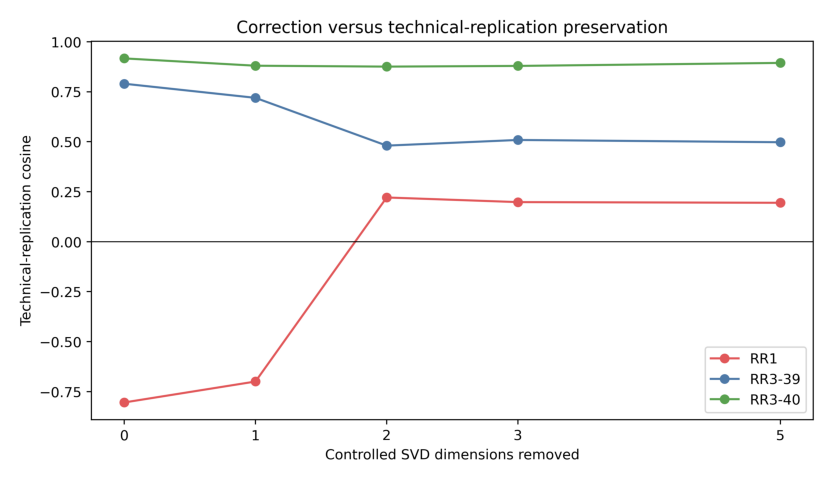

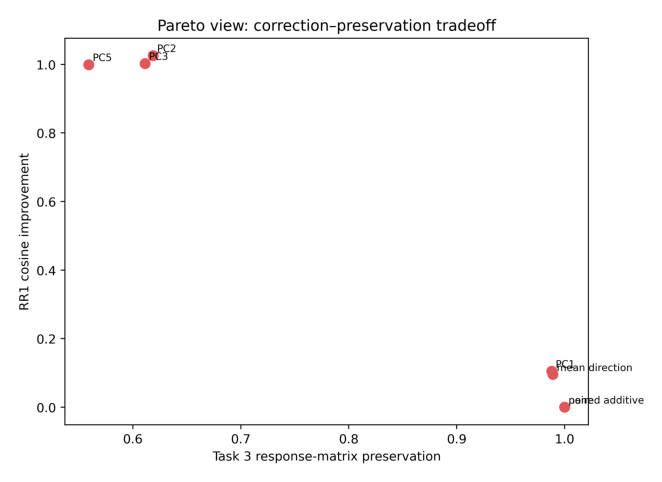

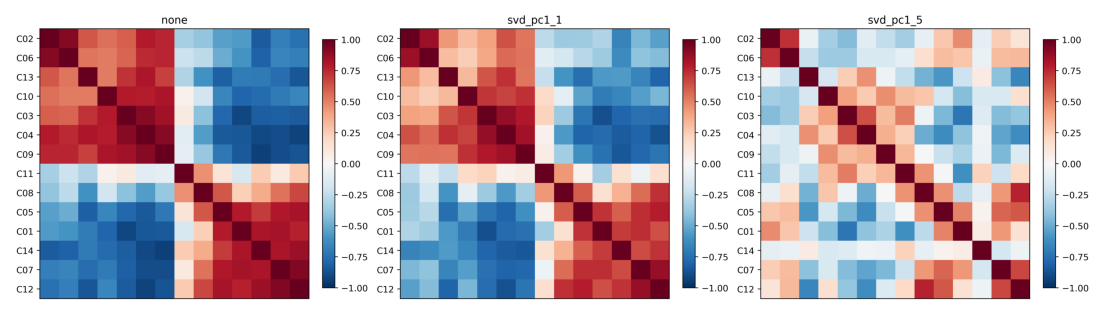

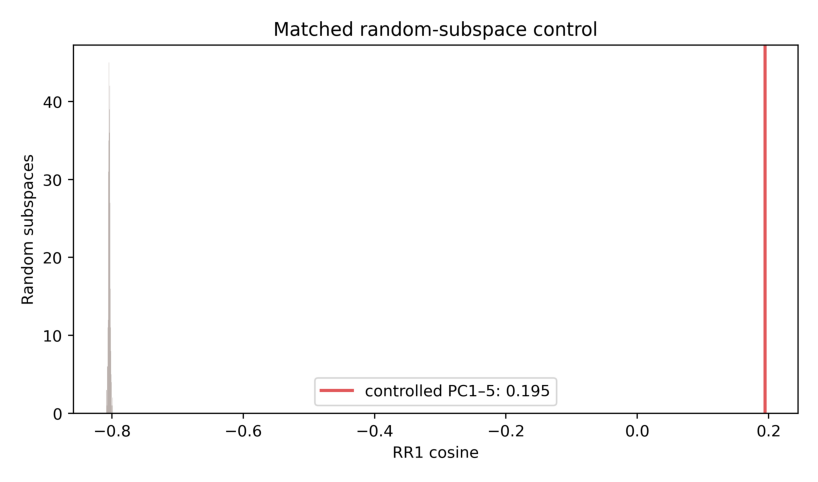

In [16]:
for name in ['figure_a_correction_curves.png','figure_b_pareto_tradeoff.png','figure_c_selected_response_matrices.png','figure_d_random_control.png']:
    img=plt.imread(simple/name);plt.figure(figsize=(14,6));plt.imshow(img);plt.axis('off');plt.show()

### Correction–preservation conclusion

1. **Was SVD projection better?** Not generally. Mean-direction projection and SVD PC1 are nearly equivalent compromises. PC2+ is uniquely capable of making RR1 positive, but only alongside substantial loss of RR3-39 and broader response organization.
2. **Controlled pair removal:** SVD PC1–5 gives the smallest paired distance and perfect donor R@1, but held-donor protocol predictions remain orientation-decodable (orientation-free AUROC 0.713). Systematic prediction inversion for several methods must not be called protocol erasure.
3. **Best preservation:** Paired additive residualization preserves RR3 and all FLT−GC response geometry exactly because its study-constant protocol offset cancels algebraically. Consequently, it leaves RR1 unchanged. Among projections, mean-direction/PC1 preserves the most structure.
4. **RR1 without substantial damage:** No evaluated method does this. PC1 improves RR1 only from −0.804 to about −0.70. PC1–2 makes RR1 positive but response-matrix preservation falls to 0.619, median response preservation to 0.541, and ARI to 0.272.
5. **PC1 versus PC1–5:** PC1 is the better preservation compromise, but it is not an RR1 solution. PC1–5 is a stronger technical perturbation with unacceptable response damage.
6. **Pareto result:** Multiple methods are non-dominated because technical removal, RR1 movement, and response preservation conflict. There is no jointly successful operating point.
7. **Recommended use:** The controlled basis is most defensible for **diagnostic quantification**, not routine correction. It identifies RR1-sensitive directions, but current evidence does not demonstrate separability of technical and biological response components.

The residual spaces are not purified biology, and none of these results imply that BridgeRNA removes batch effects.

## 9. Diagnostic decomposition of technical-replication discrepancies

This analysis does **not** correct or remove dimensions from any embedding. For each NASA technical replication it defines $\delta=\Delta z_{original}-\Delta z_{remeasurement}$ and measures how much of that discrepancy lies in the uncentered SVD basis fitted only to 40 independent same-RNA T-cell Ribo-minus-PolyA displacements. Random 1/2/3/5-dimensional subspaces provide a 1,000-replicate calibration for each comparison and dimension.

`parallel` means *aligned with the independently characterized library-associated transformation*; it is not a pure technical effect. The orthogonal component is likewise not pure biology. For cross-context directional comparisons, NASA vectors are displayed in original-to-remeasurement orientation (`-delta`) to match the controlled PolyA-to-Ribo convention.

In [17]:
diag=RESULTS/'task4_discrepancy_decomposition'
compact=read_csv(diag/'rr1_rr3_compact_comparison.csv')
display(compact.style.format(precision=4))
display(read_csv(diag/'random_subspace_calibration.csv').style.format(precision=4))

,comparison,original_replication_cosine,discrepancy_norm,PC1_alignment,fraction_PC1,fraction_PC1_2,fraction_PC1_3,fraction_PC1_5,random_percentile_PC1_5,empirical_p_PC1_5
0,RR1,-0.8041,1.3530,0.7342,0.5390,0.9531,0.9533,0.9597,1.0000,0.0010
1,RR3-39,0.7900,0.1440,0.3251,0.1057,0.1410,0.2075,0.2262,1.0000,0.0010
2,RR3-40,0.9166,0.0732,0.4820,0.2323,0.4663,0.4823,0.5603,1.0000,0.0010


,comparison,components,observed_fraction,random_median,random_q025,random_q975,empirical_percentile,empirical_p_one_sided
0,RR1,1,0.5390,0.0009,0.0000,0.0111,1.0000,0.0010
1,RR1,2,0.9531,0.0028,0.0001,0.0143,1.0000,0.0010
2,RR1,3,0.9533,0.0047,0.0005,0.0178,1.0000,0.0010
3,RR1,5,0.9597,0.0086,0.0018,0.0242,1.0000,0.0010
4,RR3-39,1,0.1057,0.0009,0.0000,0.0087,1.0000,0.0010
5,RR3-39,2,0.1410,0.0028,0.0001,0.0138,1.0000,0.0010
6,RR3-39,3,0.2075,0.0049,0.0006,0.0184,1.0000,0.0010
7,RR3-39,5,0.2262,0.0083,0.0015,0.0252,1.0000,0.0010
8,RR3-40,1,0.2323,0.0010,0.0000,0.0104,1.0000,0.0010
9,RR3-40,2,0.4663,0.0029,0.0001,0.0145,1.0000,0.0010


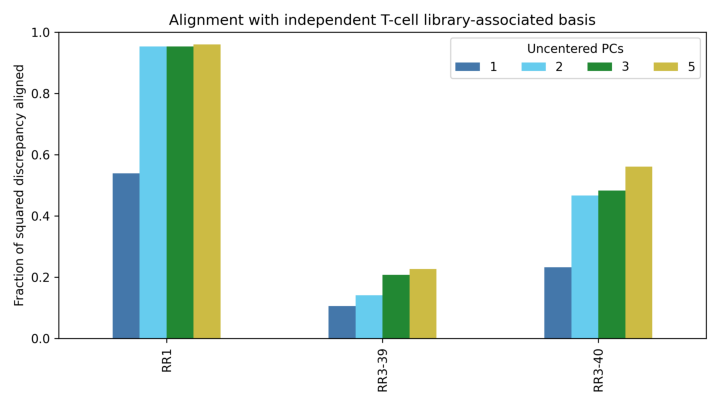

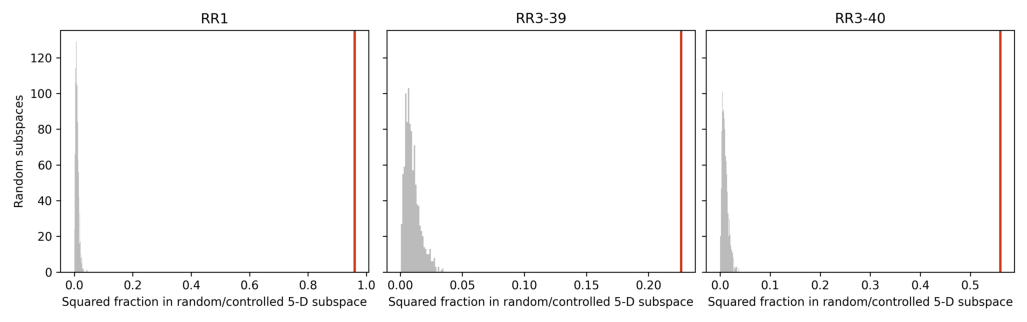

In [18]:
for name in ['discrepancy_alignment.png','random_subspace_calibration.png']:
    img=plt.imread(diag/name);plt.figure(figsize=(13,5));plt.imshow(img);plt.axis('off');plt.show()

### Additive-vector and preservation-interaction checks

The controlled donor displacements are internally coherent, but the only held-out pooled-blood and colon source vectors point in the opposite direction from the T-cell mean. Those two sources each represent only one biological source and cannot establish tissue specificity. Together with heterogeneous NASA alignment, this is inconsistent with treating one additive vector as universally transferable; a context-dependent transformation remains the more defensible working model.

The Lai Polo study explicitly reported that collection/preservation effects were exacerbated with polyA selection. Our cached OSDR design audit nevertheless does not contain the crossed, same-material combinations needed to independently estimate preservation, library selection, and their interaction. OSD-48 C13/C14 offers a preservation comparison in different animals; OSD-48 C14 to OSD-168 offers exact-material remeasurement across a broader library/sequencing transition; OSD-168 ERCC comparisons hold library and source material fixed. These pieces are informative but do not form a causal factorial design.

In [19]:
display(read_csv(diag/'additive_vector_context_alignment.csv').query("source_class != 'T-cell donor'").style.format(precision=4))
display(read_csv(diag/'preservation_library_interaction_feasibility.csv').style.hide(axis='index'))

,source,source_class,n_biological_sources,cosine_with_tcell_mean,fraction_PC1_5
40,colon,held-out blood/colon,1.0000,-0.7612,0.9714
41,pooled_blood,held-out blood/colon,1.0000,-0.6572,0.8533
42,RR1 original-to-remeasurement,NASA discrepancy,nan,0.7205,0.9597
43,RR3-39 original-to-remeasurement,NASA discrepancy,nan,0.3209,0.2262
44,RR3-40 original-to-remeasurement,NASA discrepancy,nan,0.4717,0.5603


comparison,library_selection,preservation,biological_correspondence,preservation_effect_identifiable,library_effect_identifiable,interaction_identifiable,limitation
OSD-48 C13 vs C14,polyA fixed,Mini Cold Bag vs RLT/snap frozen,different animals,partial,no,no,"Preservation differs within RR1, but biological material is not paired."
OSD-48 C14 vs OSD-168 RR1,polyA vs ribodepleted,source C14 material,exact animals/RNA-derived material,held fixed,library-associated protocol transition,no,Library changes with read layout/depth and sequencing workflow; not an isolated causal library effect.
OSD-168 RR1 no-ERCC vs ERCC,ribodepleted fixed,fixed,same source animals,no,no,no,Identifies ERCC-associated remeasurement only.
OSD-137 vs OSD-168 RR3,ribodepleted fixed,liquid nitrogen,exact source material,no,no,no,Technical resequencing control; no library or preservation contrast.
Across Lai Polo/OSDR studies,study-associated,study-associated,unpaired,confounded,confounded,not identifiable,"Mission, strain, duration, collection, library, and sequencing differ together."


### Diagnostic conclusion

RR1 has **53.9%** of squared discrepancy on controlled PC1 and **96.0%** within PC1–5. RR3-39 and RR3-40 have **22.6%** and **56.0%** within PC1–5, respectively. All three exceed 1,000 matched-dimensional random subspaces (one-sided empirical $p=0.001$ at PC1–5), so alignment is not exclusive to RR1. RR1 is nevertheless the strongest and most concentrated case, especially relative to RR3-39.

This establishes diagnostic alignment, not a causal fraction explained by library preparation. The simplest decisive next experiment is a crossed same-RNA design spanning multiple biological contexts: aliquot the same RNA under at least two preservation states and process every aliquot with both polyA selection and ribodepletion, holding sequencing workflow fixed and replicating the design across tissues/donors. That design can estimate preservation, library-associated, and interaction terms without relying on study-level confounding.

## 10. Donor-resampling robustness of the Technical Alignment Score

This robustness analysis uses only cached embeddings. It repeats the exact uncentered-SVD convention under 1,000 paired-donor bootstraps, 250 random 32-train/8-held-out donor splits, and leave-one-donor-out validation. It does not remove PCs or modify any representation.

Subspace comparisons use principal angles and projection matrices, because secondary PCs may rotate or exchange order. Bootstrap uncertainty answers reference reproducibility; held-out alignment answers donor generalization; the earlier random-subspace test answers chance geometry. These are separate questions.

In [20]:
robust_dir=RESULTS/'task4_technical_subspace_robustness'
prof=read_csv(robust_dir/'bootstrap_profiler_score_summary.csv')
sub=read_csv(robust_dir/'bootstrap_subspace_stability_summary.csv')
held=read_csv(robust_dir/'heldout_donor_alignment_summary.csv')
order=read_csv(robust_dir/'bootstrap_ordering_stability.csv')
display(prof.style.format(precision=4))
display(order.style.format(precision=4))

,comparison,components,mean,median,sd,q025,q975,min,max,n,original_full_data_score
0,RR1,1,0.5381,0.5373,0.0211,0.4969,0.5779,0.4681,0.6201,1000.0000,0.5390
1,RR3-39,1,0.1056,0.1056,0.0034,0.0990,0.1123,0.0947,0.1176,1000.0000,0.1057
2,RR3-40,1,0.2319,0.2316,0.0105,0.2117,0.2508,0.1965,0.2698,1000.0000,0.2323
3,RR1,2,0.9459,0.9476,0.0086,0.9250,0.9577,0.8910,0.9619,1000.0000,0.9531
4,RR3-39,2,0.1403,0.1400,0.0097,0.1221,0.1600,0.1125,0.1755,1000.0000,0.1410
5,RR3-40,2,0.4641,0.4643,0.0177,0.4310,0.4992,0.4053,0.5258,1000.0000,0.4663
6,RR1,3,0.9482,0.9494,0.0075,0.9293,0.9590,0.9120,0.9628,1000.0000,0.9533
7,RR3-39,3,0.1915,0.1851,0.0387,0.1363,0.2757,0.1237,0.3312,1000.0000,0.2075
8,RR3-40,3,0.4816,0.4790,0.0228,0.4417,0.5317,0.4150,0.5680,1000.0000,0.4823
9,RR1,5,0.9557,0.9566,0.0054,0.9430,0.9637,0.9273,0.9663,1000.0000,0.9597


,components,fraction_RR1_gt_RR3_40_gt_RR3_39,iterations
0,1,1.0000,1000
1,2,1.0000,1000
2,3,1.0000,1000
3,5,1.0000,1000


In [21]:
display(sub.query("metric in ['largest_principal_angle_deg','mean_principal_angle_deg','projection_similarity']").style.format(precision=4))
display(held.style.format(precision=4))

,components,metric,mean,median,sd,q025,q975,min,max,n
0,1,largest_principal_angle_deg,1.4107,1.2360,0.6199,0.6647,3.0400,0.5054,5.1446,1000.0000
1,2,largest_principal_angle_deg,7.2767,7.0121,2.2826,3.7248,12.4662,2.9185,16.7881,1000.0000
2,3,largest_principal_angle_deg,33.9369,30.0034,16.1782,14.5742,77.9795,10.8860,88.9958,1000.0000
3,5,largest_principal_angle_deg,48.5675,45.6027,16.9399,24.1284,85.7575,13.8924,89.9447,1000.0000
4,1,mean_principal_angle_deg,1.4107,1.2360,0.6199,0.6647,3.0400,0.5054,5.1446,1000.0000
5,2,mean_principal_angle_deg,4.0349,3.9037,1.1565,2.2997,6.6862,1.8613,8.8605,1000.0000
6,3,mean_principal_angle_deg,13.5276,12.1810,5.3710,7.0164,28.4335,5.0297,31.5580,1000.0000
7,5,mean_principal_angle_deg,17.5383,16.9667,4.1432,10.8661,26.2860,7.7428,31.8032,1000.0000
8,1,projection_similarity,0.9993,0.9995,0.0007,0.9972,0.9999,0.9920,0.9999,1000.0000
9,2,projection_similarity,0.9911,0.9925,0.0057,0.9766,0.9978,0.9582,0.9986,1000.0000


,validation,components,mean,median,sd,q025,q975,min,max,n
0,repeated_32_8,1,0.9709,0.9792,0.0269,0.8954,0.9932,0.8391,0.9941,2000.0000
1,repeated_32_8,2,0.9882,0.9893,0.0072,0.9658,0.9970,0.9556,0.9974,2000.0000
2,repeated_32_8,3,0.9897,0.9919,0.0068,0.9677,0.9971,0.9574,0.9974,2000.0000
3,repeated_32_8,5,0.9918,0.9936,0.0056,0.9735,0.9974,0.9656,0.9979,2000.0000
4,leave_one_donor_out,1,0.9712,0.9797,0.0276,0.9037,0.9928,0.8524,0.9932,40.0000
5,leave_one_donor_out,2,0.9884,0.9896,0.0073,0.9688,0.9970,0.9605,0.9972,40.0000
6,leave_one_donor_out,3,0.9900,0.9926,0.0069,0.9701,0.9970,0.9646,0.9972,40.0000
7,leave_one_donor_out,5,0.9921,0.9939,0.0056,0.9739,0.9974,0.9732,0.9976,40.0000


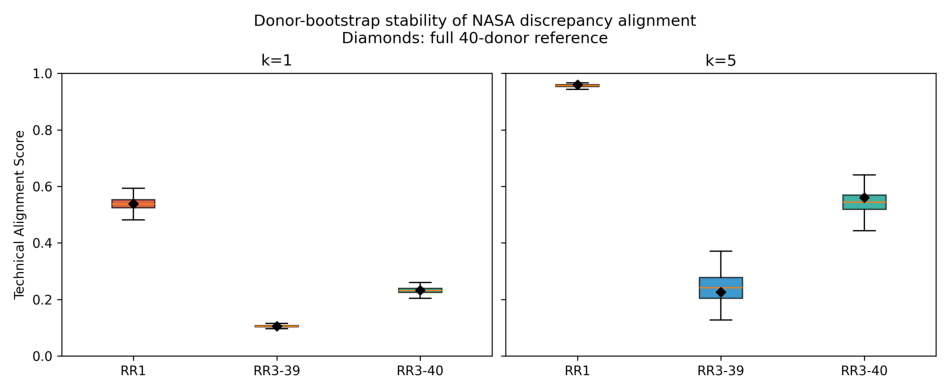

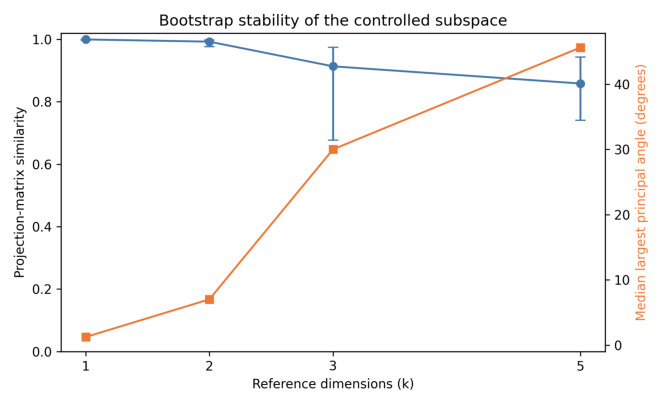

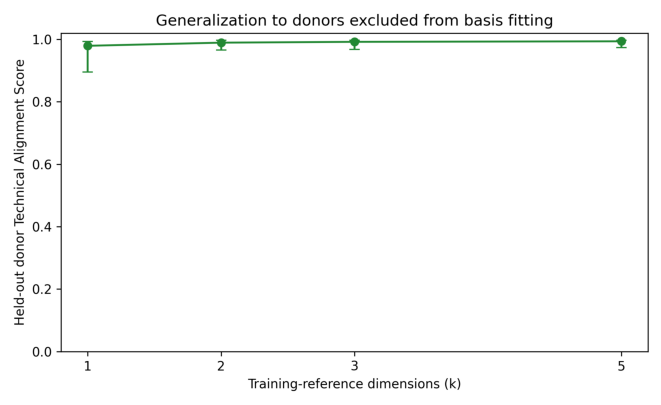

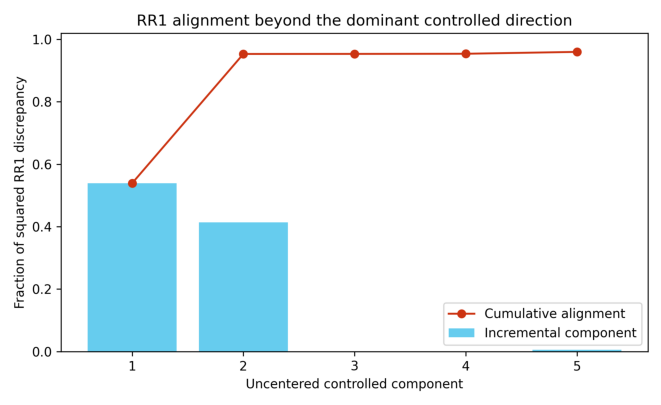

In [22]:
for name in ['figure_a_bootstrap_alignment.png','figure_b_subspace_stability.png','figure_c_heldout_donor_alignment.png','figure_d_rr1_cumulative_alignment.png']:
    img=plt.imread(robust_dir/name);plt.figure(figsize=(12,5));plt.imshow(img);plt.axis('off');plt.show()

### Secondary components and final robustness interpretation

PC1 is exceptionally stable: median bootstrap projection similarity is **0.9995**, with a median principal angle of **1.24°**. PC1–2 is also stable (median projection similarity **0.9925**; largest angle **7.01°**). The complete PC1–5 span is only moderately stable: median projection similarity is **0.8584**, and its largest principal angle is **45.60°** (95% interval 24.13°–85.76°).

Despite instability in weaker dimensions, the NASA profiler scores are stable. RR1 PC1–5 has bootstrap median **0.9566**, mean **0.9557**, SD **0.0054**, and 95% interval **0.9430–0.9637**, close to the full-reference value 0.9597. The ordering RR1 > RR3-40 > RR3-39 holds in 100% of bootstraps at every tested k.

The increase in RR1 is specifically dominated by two stable dimensions: PC1 contributes **0.5390** and PC2 contributes **0.4141**; PCs 3–5 together contribute only about **0.0066** in the full reference. Thus, the high PC1–5 score is reproducible because RR1 aligns strongly with the stable PC1–2 core—not because each of PC3–5 is individually reproducible.

The learned reference generalizes strongly within this controlled experiment. Across repeated 32/8 splits, held-out donor median alignment is **0.9792** for k=1 and **0.9936** for k=5; leave-one-donor-out values are nearly identical. This supports the Technical Alignment Score as a reproducible diagnostic of similarity to **this T-cell PolyA→Ribo transformation**. It does not establish a universal tissue-independent technical direction, causal attribution, purified biology, or successful batch correction.

## 11. BridgeRNA Technical Confounding Profiler

### Response context

**Biological system:** mouse liver  
**Perturbation:** spaceflight  
**Response:** Flight minus Ground Control  
**Comparison:** original measurement versus technical remeasurement

- **RR1:** OSD-48 versus OSD-168. PolyA, single-end 50-bp HiSeq 3000 sequencing transitions to ribodepletion, paired-end 150-bp HiSeq 4000 sequencing without ERCC; both were sequenced at UC Davis.
- **RR3-39 / RR3-40:** 39- and 40-day OSD-137 responses versus OSD-168 ERCC remeasurements. Both sides are ribodepleted, paired-end 150-bp HiSeq 4000 data from UC Davis.

The profiler keeps four questions separate: **Response Reproducibility** asks whether the response reproduced; **Technical Alignment Score** asks whether a discrepancy resembles the controlled transformation; **Biological Overlap** asks whether technical-associated structure intersects response geometry; and **Biological Impact** asks what molecular programs/features changed. They are not collapsed into one score.

$R=\cos(\Delta z_A,\Delta z_B)$ and $T=\|P_{PC1:2}\delta\|^2/\|\delta\|^2$, where $\delta=\Delta z_A-\Delta z_B$. PC1–2 is the operational reference learned from controlled same-RNA T-cell PolyA/Ribo pairs. Its cross-tissue universality has not been established. Category labels are descriptive, not inferential thresholds.

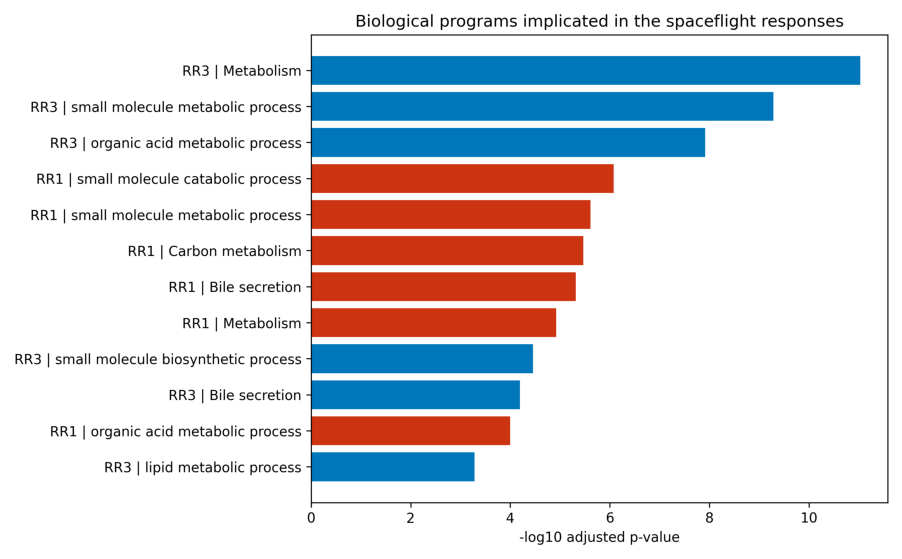

query,source,native,name,p_value,minus_log10_adjusted_p
RR3_reproducible,REAC,REAC:R-HSA-1430728,Metabolism,9.23e-12,11.03
RR3_reproducible,GO:BP,GO:0044281,small molecule metabolic process,5.17e-10,9.29
RR3_reproducible,GO:BP,GO:0006082,organic acid metabolic process,1.21e-08,7.92
RR1_shared_same_sign,GO:BP,GO:0044282,small molecule catabolic process,8.33e-07,6.08
RR1_shared_same_sign,GO:BP,GO:0044281,small molecule metabolic process,2.45e-06,5.61
RR1_shared_same_sign,KEGG,KEGG:01200,Carbon metabolism,3.41e-06,5.47
RR1_shared_same_sign,KEGG,KEGG:04976,Bile secretion,4.81e-06,5.32
RR1_shared_same_sign,REAC,REAC:R-HSA-1430728,Metabolism,1.19e-05,4.92
RR3_reproducible,GO:BP,GO:0044283,small molecule biosynthetic process,3.50e-05,4.46
RR3_reproducible,KEGG,KEGG:04976,Bile secretion,6.41e-05,4.19


In [23]:
profiler_dir=RESULTS/'task4_confounding_profiler'
profiler=read_csv(profiler_dir/'profiler_summary.csv')
img=plt.imread(profiler_dir/'biological_programs.png')
plt.figure(figsize=(12,7));plt.imshow(img);plt.axis('off');plt.show()
display(read_csv(profiler_dir/'biological_programs.csv').style.format({'p_value':'{:.2e}','minus_log10_adjusted_p':'{:.2f}'}).hide(axis='index'))

### Primary diagnostics

Biological Preservation is a **global Task 3 response-geometry statistic**, not a separate RR1/RR3 value and not a percentage of biology. It measures Spearman preservation of the complete response-similarity matrix after removal. PC1–5 is highlighted because it substantially resolves RR1.

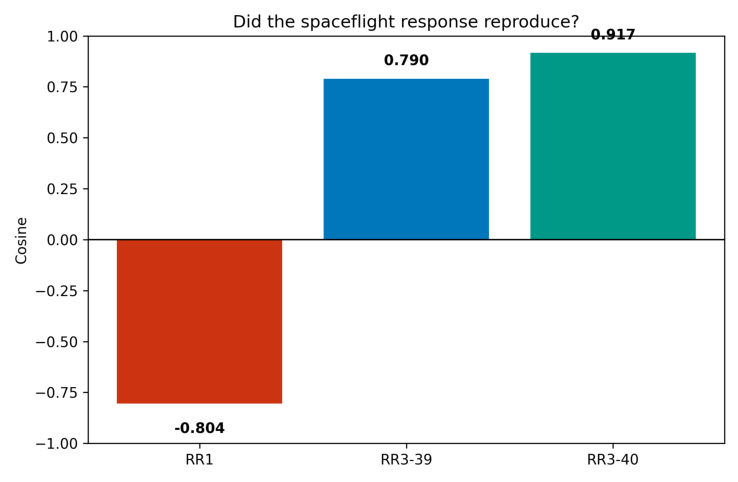

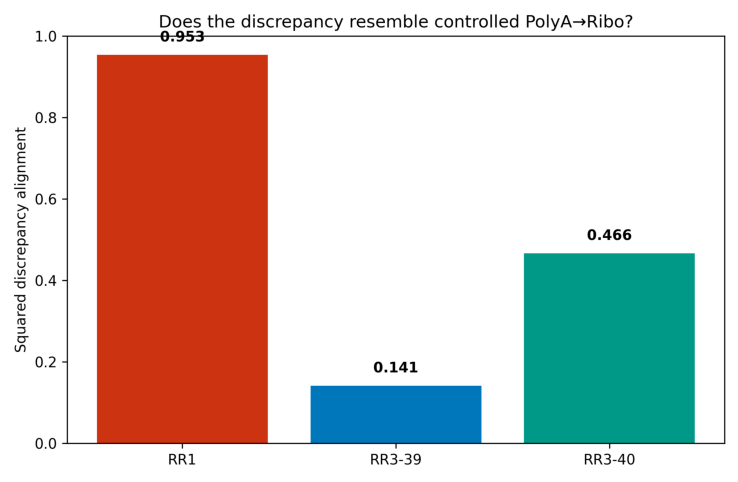

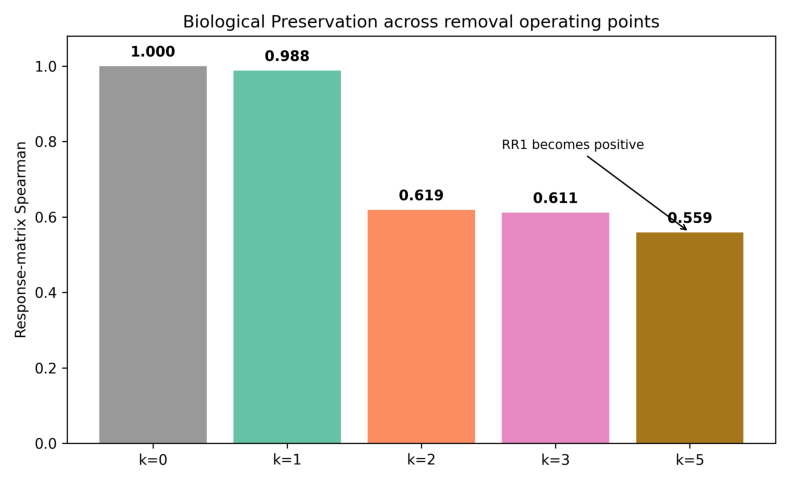

Comparison,Response Reproducibility,Response Category,Technical Alignment PC1-2
RR1,-0.804,Opposing / reversed response,0.953
RR3-39,0.790,Moderately reproducible,0.141
RR3-40,0.917,Highly reproducible,0.466


In [24]:
for name in ['response_reproducibility_bars.png','technical_alignment_bars.png','biological_preservation_bars.png']:
    img=plt.imread(profiler_dir/name);plt.figure(figsize=(10,6));plt.imshow(img);plt.axis('off');plt.show()
primary=['Comparison','Response Reproducibility','Response Category','Technical Alignment PC1-2']
display(profiler[primary].style.format({'Response Reproducibility':'{:.3f}','Technical Alignment PC1-2':'{:.3f}'}).hide(axis='index'))

### Compact experiment profiles

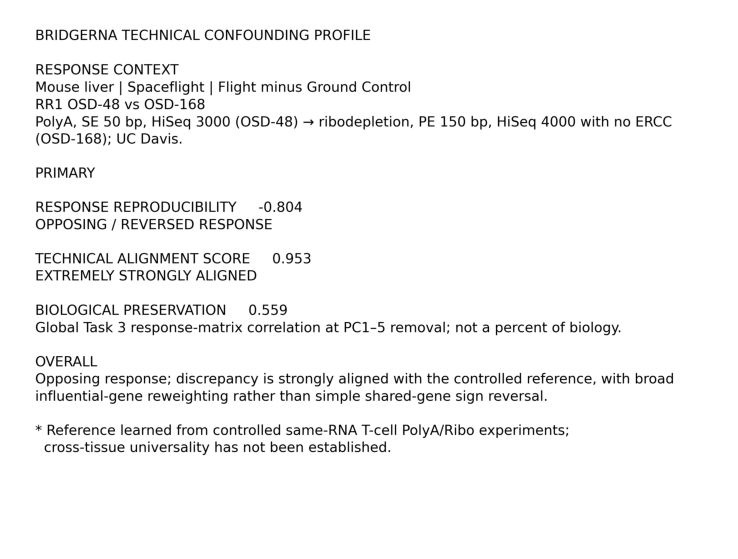

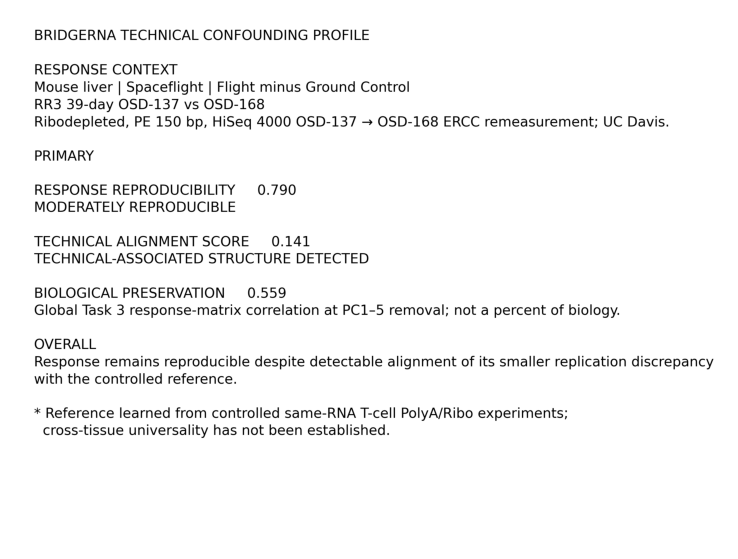

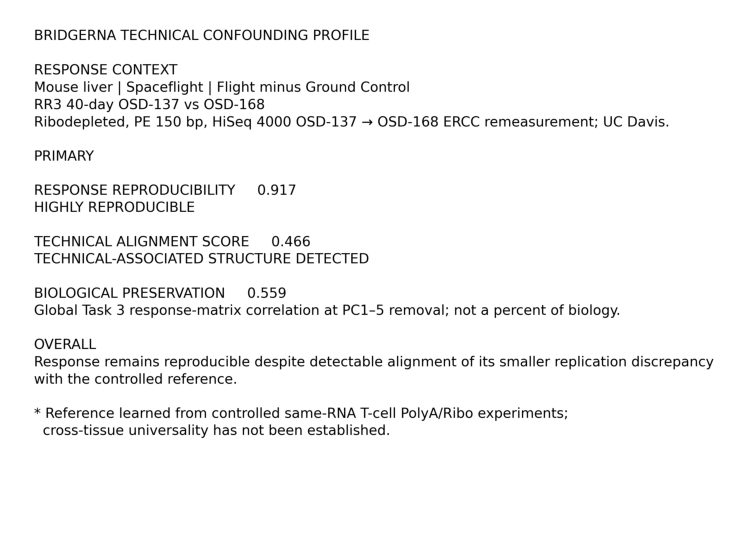

In [25]:
for name in ['rr1_profile.png','rr3_39_profile.png','rr3_40_profile.png']:
    img=plt.imread(profiler_dir/'figures'/name)
    plt.figure(figsize=(10,7));plt.imshow(img);plt.axis('off');plt.show()

The Technical Sensitivity Map remains saved as a secondary diagnostic, but it is no longer the primary display. Bar graphs keep Response Reproducibility, Technical Alignment, and Biological Preservation on separate scales.

<details><summary><b>Technical Alignment Evidence — why trust T?</b></summary>

Bootstrap uncertainty asks whether donor resampling yields the same reference. Random-subspace calibration asks whether alignment exceeds chance geometry. Held-out-donor alignment asks whether a basis learned from some controlled donors captures the transformation in unseen T-cell donors.

PC1 has projection similarity 0.9995 and median principal angle 1.24°. PC1–2 has projection similarity 0.9925 and largest angle 7.01°. Repeated 32/8 held-out-donor median PC1–2 alignment is 0.9893. Full PC1–5 is only moderately stable and is not the operational profiler reference.
</details>

In [26]:
evidence=['Comparison','Technical Alignment PC1-2','PC1 Contribution','PC2 Contribution','Bootstrap Median','Bootstrap 95% Low','Bootstrap 95% High','Random-Subspace Percentile','Random-Subspace P']
display(profiler[evidence].style.format(precision=4).hide(axis='index'))

Comparison,Technical Alignment PC1-2,PC1 Contribution,PC2 Contribution,Bootstrap Median,Bootstrap 95% Low,Bootstrap 95% High,Random-Subspace Percentile,Random-Subspace P
RR1,0.9531,0.5390,0.4141,0.9476,0.9250,0.9577,1.0000,0.0010
RR3-39,0.1410,0.1057,0.0353,0.1400,0.1221,0.1600,1.0000,0.0010
RR3-40,0.4663,0.2323,0.2339,0.4643,0.4310,0.4992,1.0000,0.0010


<details><summary><b>Biological Overlap evidence</b></summary>

At PC1 removal, RR1 changes from −0.804 to −0.699 while broader response-matrix preservation is 0.988 and mode ARI remains 1.0. At PC1–5 removal, RR1 becomes +0.195, but matrix preservation falls to 0.559 and mode ARI to 0.116. Removing enough technical-associated structure to resolve RR1 therefore reorganizes broader spaceflight-response geometry. This identifies neither pure technical dimensions nor a pure biological residual.
</details>

In [27]:
overlap=read_csv(RESULTS/'task4_simple_correction_comparison/svd_correction_curve.csv')
display(overlap.query("method in ['none','svd_pc1_1','svd_pc1_5']")[['method','RR1','RR3-39','RR3-40','response_matrix_preservation','mode_ARI']].style.format(precision=3).hide(axis='index'))

method,RR1,RR3-39,RR3-40,response_matrix_preservation,mode_ARI
none,-0.804,0.790,0.917,1.000,1.000
svd_pc1_1,-0.699,0.719,0.880,0.988,1.000
svd_pc1_5,0.195,0.497,0.894,0.559,0.116


<details><summary><b>Biological Impact</b></summary>

Gene attribution measures which input genes BridgeRNA relied upon most strongly for the response. RR1's low signed attribution concordance means its gene-level basis was substantially reweighted. Because 96.2% of shared influential genes retain direction, this is not simple reversal of the same genes.

Existing enrichment implicates lipid metabolism, bile secretion, fatty-acid/peroxisomal metabolism, and small-molecule catabolism. These are biological programs implicated in the technically sensitive latent response—not pathways labeled as technical artifacts.
</details>

In [28]:
impact=['Comparison','Attribution Spearman','Top100 Shared','Shared Top100 Sign Agreement','Measurement-Specific Top100 Union','Existing Pathway Summary']
display(profiler[impact].style.format({'Attribution Spearman':'{:.3f}','Shared Top100 Sign Agreement':'{:.1%}'}).hide(axis='index'))

Comparison,Attribution Spearman,Top100 Shared,Shared Top100 Sign Agreement,Measurement-Specific Top100 Union,Existing Pathway Summary
RR1,0.194,53,96.2%,94,"Shared same-sign genes: small-molecule catabolism, cholesterol and related hepatic metabolism."
RR3-39,0.601,71,98.6%,58,"Reproducible genes: hepatic small-molecule, organic-acid, lipid and broader metabolic programs."
RR3-40,0.597,76,100.0%,48,"Reproducible genes: hepatic small-molecule, organic-acid, lipid and broader metabolic programs."


### Contextual Gene Reproducibility — validated metric audit

Gene attribution and contextual embeddings answer different questions. IG asks which inputs most influence the final sample-level response. Here, contextual analysis asks which genes' learned relationships to the broader transcriptomic state change across remeasurement.

For each gene, $\Delta h_g=\overline h_{g,FLT}-\overline h_{g,GC}$ and Gene Context Reproducibility is $C_g=\cos(\Delta h_{g,A},\Delta h_{g,B})$. Contextual discrepancy is $\|\Delta h_{g,A}-\Delta h_{g,B}\|$; ranked enrichment uses the normalized form $D_g/(\|\Delta h_{g,A}\|+\|\Delta h_{g,B}\|)$ so negligible response vectors are not prioritized only because their cosine is noisy.

Frozen inference used the exact 34 cached Task 3 `log1p(TPM)` inputs. The audit verifies all six response memberships, the FLT-minus-GC direction, 15,165 genes, 512 contextual dimensions, unique samples within each response, and no zero response vectors. No model inference was repeated for this validation.

comparison,measurement,response_name,n_samples,n_FLT,n_GC,all_in_input_manifest,unique_within_response,FLT_minus_GC,sample_ids
RR1,A_original,RR1_OSD48_original_matched,9,4,5,True,True,True,Mmus_C57-6J_LVR_FLT_C_Rep1_M25 | Mmus_C57-6J_LVR_FLT_C_Rep2_M26 | Mmus_C57-6J_LVR_FLT_C_Rep4_M28 | Mmus_C57-6J_LVR_FLT_C_Rep5_M30 | Mmus_C57-6J_LVR_GC_C_Rep1_M36 | Mmus_C57-6J_LVR_GC_C_Rep2_M37 | Mmus_C57-6J_LVR_GC_C_Rep3_M38 | Mmus_C57-6J_LVR_GC_C_Rep4_M39 | Mmus_C57-6J_LVR_GC_C_Rep5_M40
RR1,B_remeasurement,RR1_OSD168_no-ERCC,9,4,5,True,True,True,Mmus_C57-6J_LVR_RR1_FLT_noERCC_Rep1_M25 | Mmus_C57-6J_LVR_RR1_FLT_noERCC_Rep2_M26 | Mmus_C57-6J_LVR_RR1_FLT_noERCC_Rep3_M28 | Mmus_C57-6J_LVR_RR1_FLT_noERCC_Rep5_M30 | Mmus_C57-6J_LVR_RR1_GC_noERCC_Rep1_M36 | Mmus_C57-6J_LVR_RR1_GC_noERCC_Rep2_M37 | Mmus_C57-6J_LVR_RR1_GC_noERCC_Rep3_M38 | Mmus_C57-6J_LVR_RR1_GC_noERCC_Rep4_M39 | Mmus_C57-6J_LVR_RR1_GC_noERCC_Rep5_M40
RR3-39,A_original,C01_OSD137_original_matched,4,2,2,True,True,True,Mmus_BAL-TAL_LVR_FLT_Rep1_F1 | Mmus_BAL-TAL_LVR_FLT_Rep2_F2 | Mmus_BAL-TAL_LVR_GC_Rep1_G1 | Mmus_BAL-TAL_LVR_GC_Rep2_G2
RR3-39,B_remeasurement,C01_OSD168_all_ERCC,4,2,2,True,True,True,Mmus_BAL-TAL_LVR_RR3_FLT_wERCC_Rep1_F1 | Mmus_BAL-TAL_LVR_RR3_FLT_wERCC_Rep2_F2 | Mmus_BAL-TAL_LVR_RR3_GC_wERCC_Rep1_G1 | Mmus_BAL-TAL_LVR_RR3_GC_wERCC_Rep2_G2
RR3-40,A_original,C02_OSD137_original_matched,4,2,2,True,True,True,Mmus_BAL-TAL_LVR_FLT_Rep3_F3 | Mmus_BAL-TAL_LVR_FLT_Rep4_F4 | Mmus_BAL-TAL_LVR_GC_Rep3_G3 | Mmus_BAL-TAL_LVR_GC_Rep4_G5
RR3-40,B_remeasurement,C02_OSD168_all_ERCC,4,2,2,True,True,True,Mmus_BAL-TAL_LVR_RR3_FLT_wERCC_Rep3_F3 | Mmus_BAL-TAL_LVR_RR3_FLT_wERCC_Rep4_F4 | Mmus_BAL-TAL_LVR_RR3_GC_wERCC_Rep3_G3 | Mmus_BAL-TAL_LVR_RR3_GC_wERCC_Rep4_G5


comparison,genes,zero_norm_A,zero_norm_B,magnitude_vs_cosine_spearman,directional_vs_normalized_discrepancy_spearman,median_cosine,fraction_reversed,median_normalized_discrepancy
RR1,15165,0,0,0.450,0.987,-0.125,0.616,0.766
RR3-39,15165,0,0,0.247,0.953,0.783,0.075,0.374
RR3-40,15165,0,0,0.442,0.951,0.864,0.066,0.297


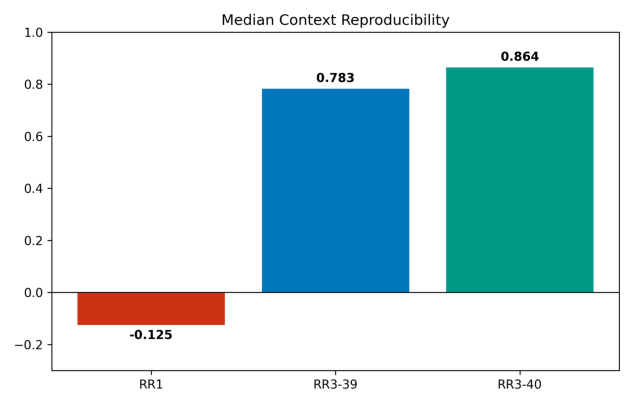

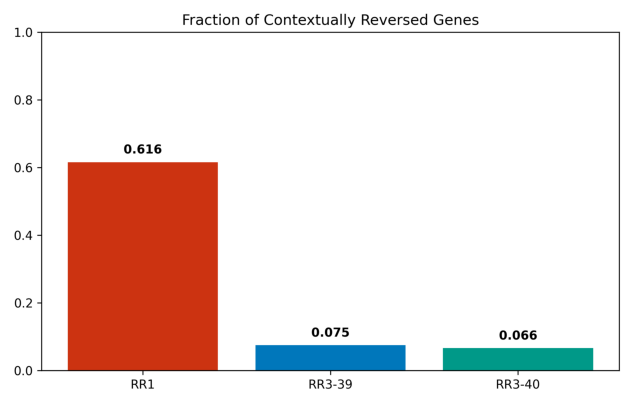

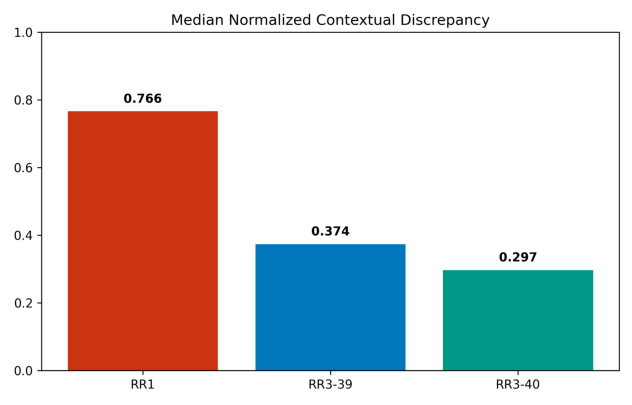

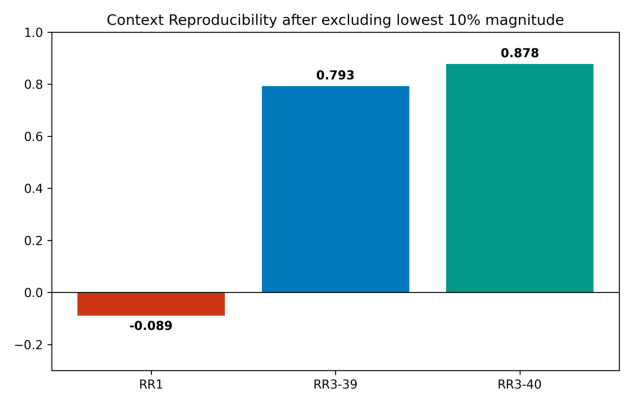

In [29]:
robust_dir=profiler_dir/'contextual_robustness'
display(read_csv(robust_dir/'sample_and_metric_audit.csv').style.hide(axis='index'))
metric_audit=read_csv(robust_dir/'metric_robustness_summary.csv')
display(metric_audit.style.format(precision=3).hide(axis='index'))
for name in ['median_context_reproducibility.png','context_reversal_fraction.png','median_normalized_discrepancy.png','magnitude_filtered_context_reproducibility.png']:
    img=plt.imread(robust_dir/'figures'/name);plt.figure(figsize=(8,5));plt.imshow(img);plt.axis('off');plt.show()

#### Low-response-norm sensitivity

The symmetric magnitude statistic is $\sqrt{\|\Delta h_A\|\|\Delta h_B\|}$. RR1's reversed genes do have lower response magnitude than its reproducible genes, so raw cosine alone overstates some instability. That does **not** explain the overall result: after removing the lowest 10% by magnitude, RR1 median cosine remains **−0.089** and 57.8% of retained genes remain reversed, versus medians **0.793** and **0.878** for RR3-39/RR3-40. Even after removing 20%, RR1 remains negative (**−0.052**).

The complementary normalized discrepancy is exactly $\|\Delta h_A-\Delta h_B\|/(\|\Delta h_A\|+\|\Delta h_B\|+\epsilon)$. RR1 median is **0.766** (0.756 after the 10% filter), compared with **0.374** and **0.297** for RR3. Directional instability and normalized discrepancy are strongly rank-correlated (RR1 Spearman **0.987**).

In [30]:
display(read_csv(robust_dir/'response_norm_by_reproducibility_group.csv').style.format(precision=3).hide(axis='index'))
display(read_csv(robust_dir/'magnitude_filter_sensitivity.csv').style.format(precision=3).hide(axis='index'))

comparison,group,genes,mean,median,q25,q75
RR1,reversed_C_lt_0,9335,0.985,0.940,0.855,1.056
RR1,poor_C_lt_0.5,13451,1.035,0.984,0.879,1.127
RR1,reproducible_C_ge_0.5,1714,2.392,1.940,1.560,2.658
RR3-39,reversed_C_lt_0,1140,0.808,0.691,0.565,0.903
RR3-39,poor_C_lt_0.5,3709,0.632,0.535,0.439,0.707
RR3-39,reproducible_C_ge_0.5,11456,0.684,0.514,0.404,0.732
RR3-40,reversed_C_lt_0,1006,0.719,0.633,0.509,0.820
RR3-40,poor_C_lt_0.5,2566,0.575,0.504,0.407,0.652
RR3-40,reproducible_C_ge_0.5,12599,0.672,0.478,0.370,0.715


comparison,lowest_magnitude_fraction_excluded,genes_retained,magnitude_cutoff,median_context_reproducibility,fraction_reversed,median_normalized_discrepancy
RR1,0.000,15165,0.676,-0.125,0.616,0.766
RR1,0.050,14406,0.792,-0.107,0.596,0.761
RR1,0.100,13648,0.821,-0.089,0.578,0.756
RR1,0.200,12132,0.870,-0.052,0.540,0.747
RR3-39,0.000,15165,0.250,0.783,0.075,0.374
RR3-39,0.050,14406,0.327,0.788,0.079,0.373
RR3-39,0.100,13648,0.354,0.793,0.083,0.375
RR3-39,0.200,12132,0.394,0.805,0.093,0.371
RR3-40,0.000,15165,0.224,0.864,0.066,0.297
RR3-40,0.050,14406,0.297,0.870,0.070,0.293


#### Ranked-GSEA audit and sensitivity

The original analysis ranked all valid BridgeRNA genes by normalized discrepancy in descending order; positive NES therefore means contextual instability and negative NES means relative contextual reproducibility. It used GO Biological Process, KEGG, and Reactome, gene sets of 10–500 tested genes, 250 permutations, and the 15,165-gene BridgeRNA universe. The repeated 0.004 values were the empirical resolution imposed by 250 permutations (approximately $1/(250+1)$; GSEApy reports its finite-permutation floor).

The validation reruns **only enrichment** with 1,000 permutations (observed nominal/FDR floor 0.001) and two rankings: normalized discrepancy, and negative cosine after excluding the bottom 10% of genes by contextual-response magnitude. Gene sets are intersected with each tested BridgeRNA universe. Enrichment therefore describes programs represented within BridgeRNA's vocabulary, not the complete mouse transcriptome. A pathway is called robust below only when it is FDR < 0.05 with the same NES direction under both rankings.

ranking_statistics,gene_universe_full,gene_universe_filtered,databases,min_gene_set_size,max_gene_set_size,permutations,seed,p_value,FDR,previous_floor,current_nominal_resolution_approx,background_note
"{'normalized_discrepancy': 'norm(A-B)/(norm(A)+norm(B)+epsilon), descending', 'magnitude_filtered_negative_cosine': '-cosine(A,B), descending after excluding bottom 10% by sqrt(normA*normB)'}",15165,13648,"['GO:BP', 'KEGG', 'REAC']",10,500,1000,42641,gseapy phenotype-label permutation empirical nominal p,gseapy permutation-based FDR q-value,0.003984,0.000999,"Ranked universes are restricted to valid BridgeRNA canonical genes; gene sets are intersected with that tested universe. Results describe programs represented within the BridgeRNA vocabulary, not the complete mouse transcriptome."


comparison,robust_unstable_terms,robust_stable_terms
RR1,294,144
RR3-39,2,15
RR3-40,0,50


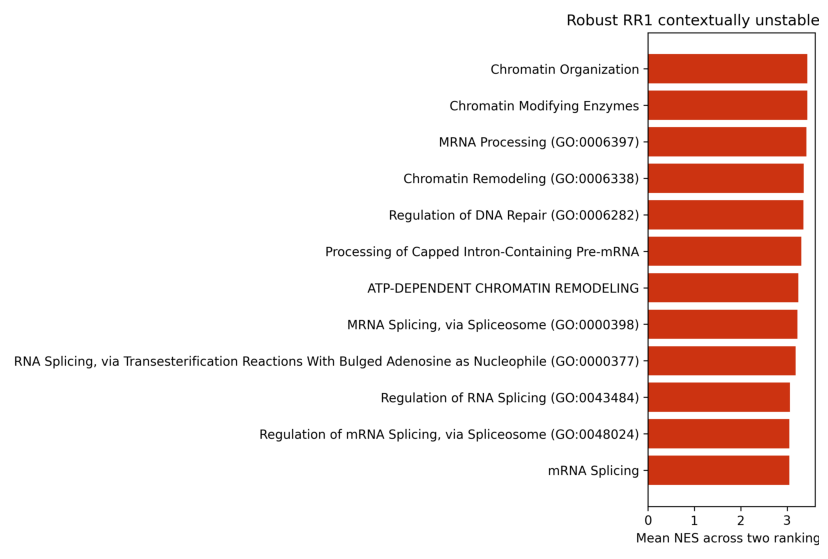

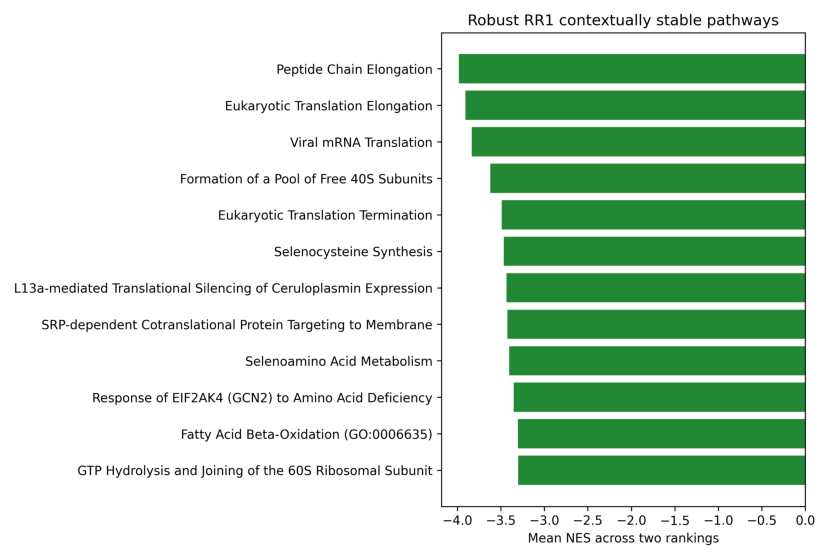

In [31]:
display(pd.DataFrame([read_json(robust_dir/'gsea_audit.json')]).style.hide(axis='index'))
unstable=read_csv(robust_dir/'robust_unstable_pathways.csv')
stable=read_csv(robust_dir/'robust_stable_pathways.csv')
display(pd.DataFrame([
 {'comparison':c,'robust_unstable_terms':len(unstable.query('comparison == @c')),'robust_stable_terms':len(stable.query('comparison == @c'))}
 for c in ['RR1','RR3-39','RR3-40']]).style.hide(axis='index'))
for name in ['robust_rr1_unstable_pathways.png','robust_rr1_stable_pathways.png']:
    path=robust_dir/'figures'/name
    if path.exists():
        img=plt.imread(path);plt.figure(figsize=(11,7));plt.imshow(img);plt.axis('off');plt.show()

RR1 RNA processing/splicing, chromatin organization/remodeling, and DNA repair/metabolism are **robust** across both defensible rankings. Their leading-edge genes have substantial contextual-response magnitudes (family medians approximately 0.93–1.00), non-negligible expression, and high normalized discrepancy; they are not dominated by zero vectors. Redundant GO terms share many leading-edge genes, so these are three broad program families rather than hundreds of independent discoveries.

Fatty-acid beta-oxidation, respiration, peroxisomal/lipid metabolism, and several translation programs consistently occupy the **relatively stable** end. “Stable” means their contextual FLT−GC response is comparatively reproducible across technical remeasurement—not unchanged biologically.

In [32]:
families=read_csv(robust_dir/'rr1_major_pathway_families.csv')
display(families.groupby(['family','ranking']).agg(pathways=('pathway','nunique'),best_NES=('nes','max'),best_FDR=('fdr','min')).reset_index().style.format({'best_NES':'{:.3f}','best_FDR':'{:.3g}'}).hide(axis='index'))
leading=read_csv(robust_dir/'leading_edge_gene_audit.csv')
display(leading.query("comparison == 'RR1'").sort_values('normalized_context_discrepancy',ascending=False)[['gene_symbol','context_reproducibility','original_response_norm','remeasurement_response_norm','normalized_context_discrepancy','mean_log1p_tpm','in_IG_Top100_union','pathway']].drop_duplicates('gene_symbol').head(25).style.format(precision=3).hide(axis='index'))

family,ranking,pathways,best_NES,best_FDR
Chromatin organization / remodeling,magnitude_filtered_negative_cosine,13,2.898,0.001
Chromatin organization / remodeling,normalized_discrepancy,14,3.973,0.001
DNA repair / DNA metabolism,magnitude_filtered_negative_cosine,4,2.541,0.001
DNA repair / DNA metabolism,normalized_discrepancy,6,4.161,0.001
RNA processing / splicing,magnitude_filtered_negative_cosine,133,2.890,0.001
RNA processing / splicing,normalized_discrepancy,163,3.949,0.001


gene_symbol,context_reproducibility,original_response_norm,remeasurement_response_norm,normalized_context_discrepancy,mean_log1p_tpm,in_IG_Top100_union,pathway
ZNF397,-0.927,2.240,1.760,0.982,2.612,False,Negative Regulation of RNA Biosynthetic Process (GO:1902679)
RBM14,-0.918,2.138,1.965,0.979,2.458,False,"Regulation of mRNA Splicing, via Spliceosome (GO:0048024)"
CPSF6,-0.906,1.834,2.783,0.977,2.459,False,MRNA Metabolic Process (GO:0016071)
RNPC3,-0.891,1.705,2.066,0.973,2.501,False,RNA Splicing (GO:0008380)
ZGPAT,-0.883,2.436,1.791,0.971,3.277,False,Negative Regulation of RNA Biosynthetic Process (GO:1902679)
UBE2V1,-0.828,5.081,1.367,0.971,3.540,False,DNA Metabolic Process (GO:0006259)
SFPQ,-0.883,1.891,1.672,0.970,3.666,False,"Alternative mRNA Splicing, via Spliceosome (GO:0000380)"
EARS2,-0.866,1.736,1.611,0.966,2.500,False,AMINOACYL-TRNA BIOSYNTHESIS
YTHDC1,-0.865,1.640,1.608,0.966,3.486,False,"MRNA Splicing, via Spliceosome (GO:0000398)"
HNRNPU,-0.860,1.686,1.162,0.966,4.306,False,Regulation of Transcription Elongation by RNA Polymerase II (GO:0034243)


#### Why RR3-39 produced visual/epidermal terms

Most RR3-39 phototransduction, keratinization, cornified-envelope, and intermediate-filament findings are low-expression and ranking-dependent. Cornified/keratin terms have leading-edge median `log1p(TPM)` around 0.01–0.06 and do not recur under both rankings. Two nearly identical light-detection GO terms do recur; they are driven by the same small, annotation-redundant set of about 9–11 low-expression genes. Their response norms are not near zero, so this is not solely a cosine singularity, but there is no liver-biological support here. We classify the phototransduction result as a **low-expression, annotation-redundant unresolved signal**, and the epidermal terms as **metric-dependent exploratory findings**, not biology.

In [33]:
display(read_csv(robust_dir/'rr3_39_suspicious_pathway_audit.csv').style.format(precision=3).hide(axis='index'))
display(read_csv(profiler_dir/'contextual_gene_overlap.csv').style.hide(axis='index'))

source,pathway,ranking,leading_edge_genes,median_expression,median_combined_magnitude,median_context_cosine,median_normalized_discrepancy
GO:BP,Detection of Light Stimulus Involved in Sensory Perception (GO:0050962),magnitude_filtered_negative_cosine,11,0.107,0.873,0.158,0.758
GO:BP,Detection of Light Stimulus Involved in Sensory Perception (GO:0050962),normalized_discrepancy,9,0.107,0.873,-0.004,0.869
GO:BP,Detection of Light Stimulus Involved in Visual Perception (GO:0050908),magnitude_filtered_negative_cosine,11,0.107,0.873,0.158,0.758
GO:BP,Detection of Light Stimulus Involved in Visual Perception (GO:0050908),normalized_discrepancy,9,0.107,0.873,-0.004,0.869
GO:BP,Intermediate Filament Organization (GO:0045109),normalized_discrepancy,35,0.029,0.820,0.281,0.724
GO:BP,Sensory Perception of Light Stimulus (GO:0050953),normalized_discrepancy,82,0.149,0.784,0.141,0.773
GO:BP,Visual Perception (GO:0007601),normalized_discrepancy,84,0.149,0.802,0.141,0.772
KEGG,CORNIFIED ENVELOPE FORMATION,normalized_discrepancy,69,0.058,0.816,0.249,0.690
KEGG,PHOTOTRANSDUCTION,normalized_discrepancy,16,0.161,1.040,-0.090,0.904
REAC,Activation of the Phototransduction Cascade,normalized_discrepancy,8,0.448,1.375,-0.148,0.892


comparison,unstable_top_n,reference,reference_genes,overlap,genes
RR1,100,IG_Top100_union,147,1,SLC39A2
RR1,100,controlled_Top100,100,3,HSD17B1;LENG8;RBM15
RR1,100,existing_interpretation_sets,147,1,SLC39A2
RR3-39,100,IG_Top100_union,129,0,nan
RR3-39,100,controlled_Top100,100,1,CXCR5
RR3-39,100,existing_interpretation_sets,0,0,nan
RR3-40,100,IG_Top100_union,124,0,nan
RR3-40,100,controlled_Top100,100,1,LRRC75A
RR3-40,100,existing_interpretation_sets,0,0,nan


#### Contextual audit decision

- **Contextual-gene result: ROBUST.** RR1 remains dramatically less reproducible than RR3 after magnitude filtering and under normalized discrepancy.
- **RR1 RNA processing/splicing: robust.**
- **RR1 chromatin organization/remodeling: robust.**
- **RR1 DNA repair/metabolism: robust.**
- **RR1 fatty-acid/peroxisomal metabolism: robust relative stability**, not instability.
- **RR3-39 phototransduction: unresolved low-expression/annotation-redundant signal.**
- **RR3-39 keratinization/cornified envelope: exploratory and metric-dependent.**

The unstable RR1 pathway leading edges overlap little with Top-100 IG genes. This is expected rather than a failed validation: IG asks which input genes most influence the final sample response, whereas contextual reproducibility asks which genes' learned contextual responses fail to reproduce. Here they identify mostly different genes and partly different programs.

### Final controlled PolyA/Ribo contextual-gene validation

This final Task 4 analysis asks whether the RR1 programs above are independently sensitive when **only library selection is changed**. It uses Chen et al.'s 40 healthy-donor naive-CD4 T-cell RNA samples, each split into a PolyA-selected and rRNA-depleted library. Frozen BridgeRNA inference uses the established checkpoint, count-to-gene-length-TPM-to-natural-`log1p` preprocessing, canonical gene order, and zero filling for absent vocabulary genes. All 40 authoritative donor pairs and all 15,165 model genes are retained (15,120 observed in the source).

For donor $i$ and gene $g$, $d_{g,i}=h_{g,Ribo,i}-h_{g,PolyA,i}$. Directional consistency is the mean cosine between each donor displacement and the mean of the other 39 donors. Prevalence is the fraction of donors with positive leave-one-out cosine. The transparent primary sensitivity score is median displacement magnitude multiplied by the positive part of mean leave-one-out consistency. The sensitivity ranking uses $\|ar d_g\|$ as an independent magnitude-aware alternative.

donors,libraries,genes,genes_observed,context_dimensions,median_loo_consistency,fraction_genes_consistency_positive,fraction_genes_majority_aligned,bootstrap_median_score_spearman,bootstrap_median_top500_overlap,permutation_p_median_consistency,rr1_controlled_gene_rank_spearman,overall_classification,supported_families,checkpoint,preprocessing,pairing,ranking,caveat
40,80,15165,15120,512,0.9592,1.0000,1.0000,0.9934,485.0000,0.0010,0.1632,PARTIAL CONCORDANCE,"['RNA processing / splicing', 'Chromatin organization / remodeling', 'DNA repair / DNA metabolism']",model/r7hnr92k/best_model.pt,counts -> gene-length TPM -> natural log1p; canonical order; absent genes zero-filled,40 authoritative same-RNA donor pairs,"primary: median displacement magnitude * max(mean LOO directional cosine, 0); sensitivity: norm(mean donor displacement)","Controlled T-cell library-selection sensitivity is independent evidence, not causal identification of the multi-factor RR1 protocol transition."


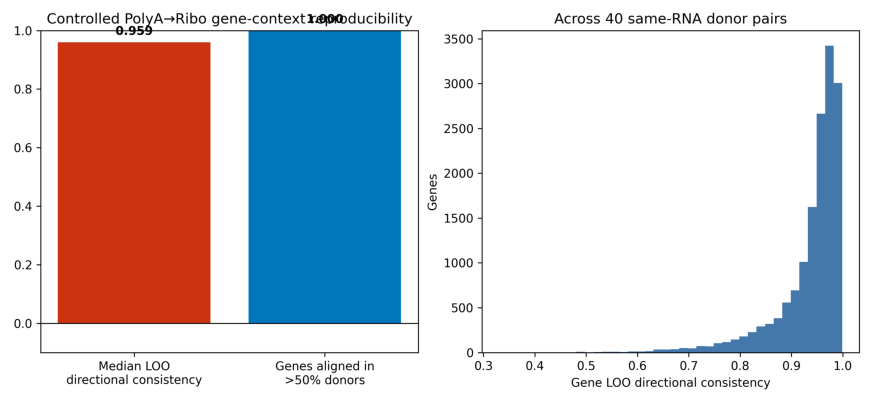

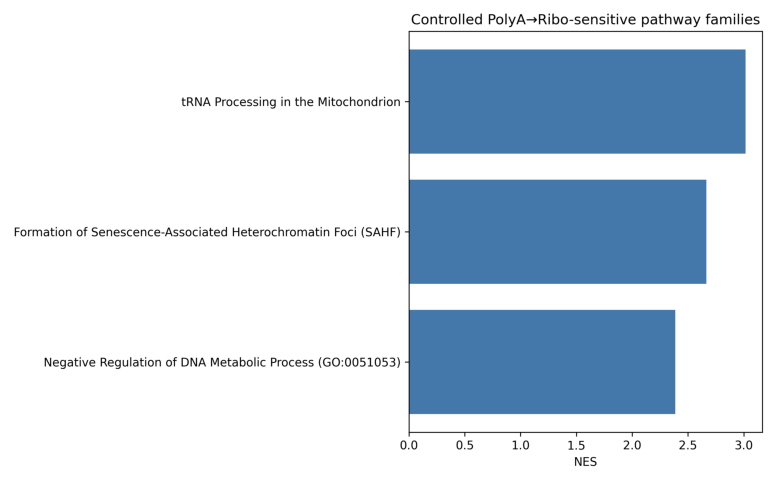

In [34]:
controlled_dir=profiler_dir/'controlled_gene_context'
controlled_summary=read_json(controlled_dir/'final_summary.json')
display(pd.DataFrame([controlled_summary]).style.format(precision=4).hide(axis='index'))
for name in ['controlled_context_reproducibility.png','controlled_sensitive_pathways.png']:
    path=controlled_dir/'figures'/name
    if path.exists():
        img=plt.imread(path);plt.figure(figsize=(11,6));plt.imshow(img);plt.axis('off');plt.show()

#### Is the controlled gene-context effect reproducible?

Yes, within this controlled T-cell experiment. Median gene-level leave-one-donor-out directional consistency is **0.959**; every gene has positive mean consistency and a majority of donors aligned with its consensus. Across 250 donor bootstraps, the median gene-ranking Spearman correlation is **0.993** and the median Top-500 overlap is **485/500**. A 1,000-replicate donor-direction sign-flip control gives empirical $p=0.001$ for the observed median consistency.

This establishes a reproducible contextual transformation in these donors. It does not establish that its size or direction is universal across cell types.

In [35]:
display(read_csv(controlled_dir/'bootstrap_ranking_stability.csv').describe().style.format(precision=3))
controlled_genes=pd.read_parquet(controlled_dir/'controlled_gene_sensitivity.parquet')
display(controlled_genes.head(25).style.format(precision=3).hide(axis='index'))

,bootstrap,score_spearman,top100_overlap,top500_overlap
count,250.000,250.000,250.000,250.000
mean,124.500,0.993,98.152,485.344
std,72.313,0.002,0.855,3.522
min,0.000,0.981,96.000,476.000
25%,62.250,0.992,98.000,483.000
50%,124.500,0.993,98.000,485.000
75%,186.750,0.994,99.000,488.000
max,249.000,0.997,100.000,493.000


gene_symbol,mean_displacement_magnitude,median_displacement_magnitude,loo_directional_consistency,donor_prevalence_aligned,consensus_strength,sensitivity_score,mean_log1p_tpm,sensitivity_rank,mean_consensus_displacement
TMEM200B,27.642,27.861,0.999,1.000,0.999,27.825,1.850,1,27.609
JSRP1,27.311,27.318,0.997,1.000,0.998,27.248,2.333,2,27.247
CERKL,26.186,26.230,0.998,1.000,0.998,26.188,2.182,3,26.146
H1-4,24.446,24.508,0.996,1.000,0.997,24.418,4.212,4,24.361
H1-3,22.978,23.031,0.996,1.000,0.996,22.941,3.644,5,22.893
SNX22,21.892,21.996,0.998,1.000,0.998,21.943,2.347,6,21.843
MASP2,21.337,21.581,0.998,1.000,0.998,21.543,1.877,7,21.302
DEGS2,20.993,21.116,0.999,1.000,0.999,21.084,1.728,8,20.963
SYNC,20.931,20.722,0.997,1.000,0.998,20.669,1.469,9,20.881
LHX4,19.755,19.754,0.999,1.000,0.999,19.732,1.418,10,19.734


#### Controlled pathway sensitivity and RR1 concordance

Preranked GSEA uses the same GO BP, KEGG, Reactome, 10–500 represented-gene limits, 15,165-gene universe, and 1,000 permutations as the validated RR1 audit. Both rankings incorporate magnitude: the primary median-magnitude × reproducibility score and the norm of the mean donor displacement.

RNA processing/splicing, chromatin organization/remodeling, and DNA repair/metabolism are **SUPPORTED** by the controlled experiment because each appears significantly at the sensitive end under both rankings. Thus, the same three broad pathway families independently recur in RR1 and a controlled library-selection perturbation.

Direct gene identity is different. Representative leading edges share **0 genes** for all three families, and RR1-versus-controlled gene rankings correlate only **0.163**. Top-N overlap is not significant at 100, 250, or 500; it becomes modestly enriched only at Top-1000 (85 observed versus 65.9 expected; $p=0.0088$). The result is therefore pathway-level convergence involving different genes—not evidence that the same individual genes transmit the effect in T cells and liver.

family,controlled_classification
RNA processing / splicing,SUPPORTED
Chromatin organization / remodeling,SUPPORTED
DNA repair / DNA metabolism,SUPPORTED
Fatty-acid / lipid metabolism,NOT SUPPORTED


family,controlled_significant_terms,rr1_significant_terms,controlled_best_nes,controlled_best_fdr,rr1_best_nes,rr1_best_fdr
RNA processing / splicing,2,78,3.017,0.001,3.949,0.001
Chromatin organization / remodeling,1,15,2.664,0.001,3.973,0.001
DNA repair / DNA metabolism,1,6,2.386,0.004,4.161,0.001
Fatty-acid / lipid metabolism,0,34,—,—,-1.574,0.001


family,rr1_leading_edge_genes,controlled_leading_edge_genes,overlap,expected_overlap,hypergeom_p
RNA processing / splicing,146,12,0,0.12,1
Chromatin organization / remodeling,139,5,0,0.05,1
DNA repair / DNA metabolism,79,7,0,0.04,1


comparison,rr_metric,spearman,genes
RR1,normalized_context_discrepancy,0.163,15165
RR1,directional_instability,0.156,15165
RR3-39,normalized_context_discrepancy,-0.111,15165
RR3-39,directional_instability,-0.109,15165
RR3-40,normalized_context_discrepancy,-0.044,15165
RR3-40,directional_instability,-0.048,15165


comparison,top_n,observed_overlap,expected_overlap,fold_enrichment,hypergeom_p
RR1,100,2,0.7,3.03,0.141
RR1,250,4,4.1,0.97,0.593
RR1,500,19,16.5,1.15,0.294
RR1,1000,85,65.9,1.29,0.0088
RR3-39,100,5,0.7,7.58,0.000517
RR3-39,250,9,4.1,2.18,0.0231
RR3-39,500,32,16.5,1.94,0.000274
RR3-39,1000,85,65.9,1.29,0.0088
RR3-40,100,2,0.7,3.03,0.141
RR3-40,250,7,4.1,1.70,0.12


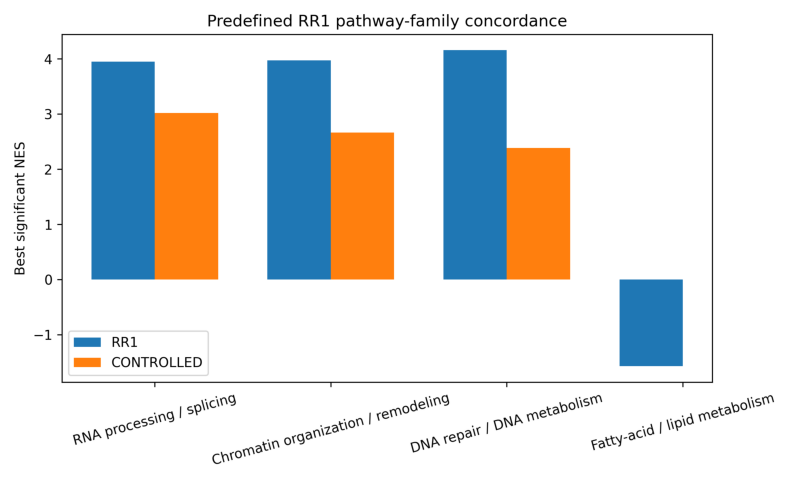

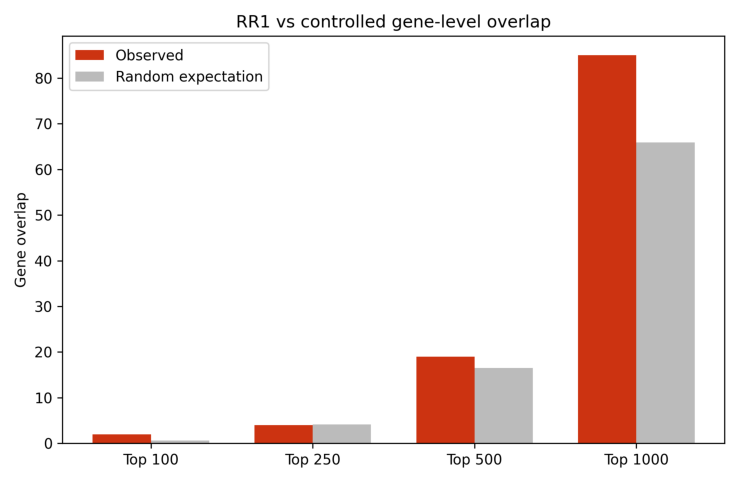

In [36]:
display(read_csv(controlled_dir/'pathway_family_decisions.csv').style.hide(axis='index'))
display(read_csv(controlled_dir/'rr1_controlled_pathway_concordance.csv').style.format(precision=3,na_rep='—').hide(axis='index'))
display(read_csv(controlled_dir/'leading_edge_concordance.csv').style.format({'expected_overlap':'{:.2f}','hypergeom_p':'{:.3g}'}).hide(axis='index'))
display(read_csv(controlled_dir/'rr1_rr3_rank_correlations.csv').style.format(precision=3).hide(axis='index'))
display(read_csv(controlled_dir/'rr1_rr3_topn_overlap.csv').style.format({'expected_overlap':'{:.1f}','fold_enrichment':'{:.2f}','hypergeom_p':'{:.3g}'}).hide(axis='index'))
for name in ['rr1_controlled_pathway_concordance.png','rr1_controlled_gene_overlap.png']:
    img=plt.imread(controlled_dir/'figures'/name);plt.figure(figsize=(10,6));plt.imshow(img);plt.axis('off');plt.show()

#### RR3 comparator and comparatively stable hepatic programs

Controlled sensitivity is positively associated with RR1 instability but negatively associated with RR3-39/40 instability (Spearman **−0.111/−0.044**), supporting preferential—but weak—RR1 correspondence. Threshold overlaps are not uniquely RR1, however; RR3-39 has stronger small-Top-N overlap. This prevents claiming a specific gene-level RR1 signature.

Fatty-acid/lipid metabolism is **NOT SUPPORTED as a controlled sensitive family** across both magnitude-aware rankings. RR1 places fatty-acid oxidation toward relative contextual stability, while the controlled T-cell result is mixed and sparse. Because the controlled biological context is naive T cells rather than liver, this cannot establish general library insensitivity of hepatic metabolism; it only says that strong controlled sensitivity was not reproduced here.

#### Final Task 4 controlled-impact conclusion

1. Controlled PolyA→Ribo selection produces a highly reproducible contextual-gene transformation across these 40 same-RNA donors.
2. The strongest individual genes include histone/chromatin-related and other high-displacement features, but the ranking should be interpreted as T-cell-context sensitivity rather than a universal technical gene list.
3. RNA processing/splicing, chromatin organization/remodeling, and DNA repair/metabolism independently recur under controlled library selection.
4. Concordance with RR1 is primarily **pathway-level, not gene-level**: genome-wide rank correlation is weak and representative leading edges do not overlap.
5. Fatty-acid/hepatic metabolic stability cannot be generalized from T cells; the controlled result is mixed and does not robustly mark this family as sensitive.
6. Evidence is **PARTIAL CONCORDANCE**: strong sample-level alignment, robust controlled gene-context transformation, and shared pathway families, but weak individual-gene correspondence.
7. RR1 also changed library chemistry, read configuration/length, instrument, depth, and other workflow details. Controlled PolyA/Ribo sensitivity therefore strengthens the library-selection hypothesis without causally identifying it as the sole source of RR1 instability.

**Paper-safe statement:** Although the RR1 replication discrepancy strongly aligned with the controlled PolyA/Ribo reference at the sample level, concordance at gene-context and pathway levels was partial. The same broad RNA-processing, chromatin, and DNA-repair families were independently sensitive to controlled library selection, but different leading-edge genes drove the T-cell and liver results. This is consistent with context dependence and the multiple technical changes separating OSD-48 and OSD-168.

The planned Task 4 evidence is now sufficient to **freeze this benchmark for the paper**, provided the claims remain diagnostic and associative: no batch correction, purified biological space, universal T-cell reference, or sole PolyA/Ribo causality is claimed.

### Conventional Expression Baseline

This baseline asks whether BridgeRNA's final contextual pathway result is already recoverable from standard raw-count differential expression. It changes no contextual analysis and reruns no model inference.

- **Controlled T cells:** edgeR quasi-likelihood paired model `~ donor + library_prep`, testing Ribo versus PolyA across 40 same-RNA donors.
- **RR1:** edgeR quasi-likelihood model on the exact nine animal-matched OSD-48/OSD-168 pairs, with animal blocking and a Measurement × FlightStatus interaction. The reported effect is `(FLT−GC)_OSD48 − (FLT−GC)_OSD168`; it is not the OSD-48 versus OSD-168 abundance difference.
- edgeR's standard `filterByExpr`, TMM normalization, robust dispersion estimation, and quasi-likelihood testing are used. The tested universes contain 11,373 T-cell and 11,916 RR1 genes from the same 15,165-gene input universe.
- T-cell ranked GSEA uses signed `sign(logFC) × sqrt(QLF)`; RR1 response-instability GSEA uses `sqrt(QLF)`. The same pathway files, 10–500 represented-gene limits, and 1,000 permutations are used.

method_tcell,method_rr1,tcell_samples,tcell_donors,tcell_genes_input,tcell_genes_tested,rr1_samples,rr1_animals,rr1_genes_input,rr1_genes_tested,tcell_expression_context_spearman,rr1_expression_context_spearman,predefined_families_shared_conventional,predefined_families_shared_bridge_context,classification
edgeR quasi-likelihood paired model: ~ donor + library_prep; Ribo vs PolyA,edgeR quasi-likelihood paired animal-blocked model; OSD48-vs-OSD168 FLT-GC interaction,80,40,15165,11373,18,9,15165,11916,0.581,0.075,1,3,AMPLIFICATION/REORGANIZATION OF CONVENTIONAL SIGNAL


analysis,T-cell result,RR1 result,Cross-context pathway concordance
Conventional expression,"RNA, chromatin, and DNA-repair families detected",RNA processing detected; chromatin and DNA repair not detected,1/3 predefined families; 0 exact significant pathways
BridgeRNA contextual genes,"RNA, chromatin, and DNA-repair families detected","RNA, chromatin, and DNA-repair families detected",3/3 predefined families; 9 exact significant pathways


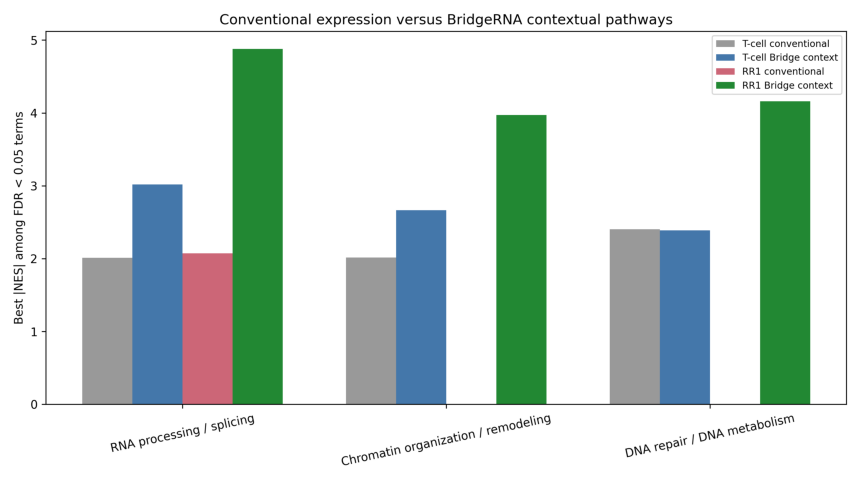

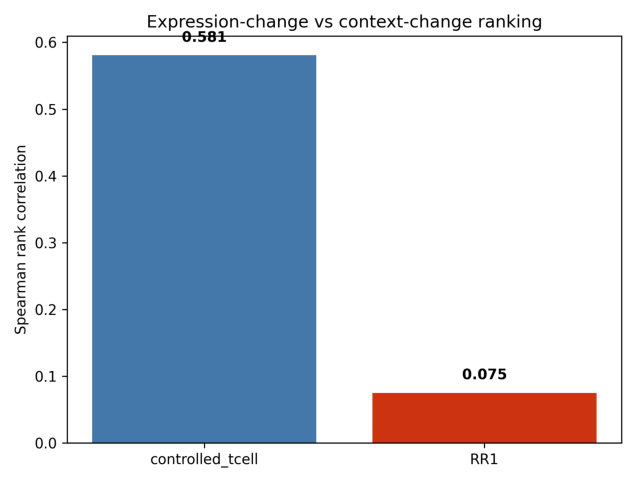

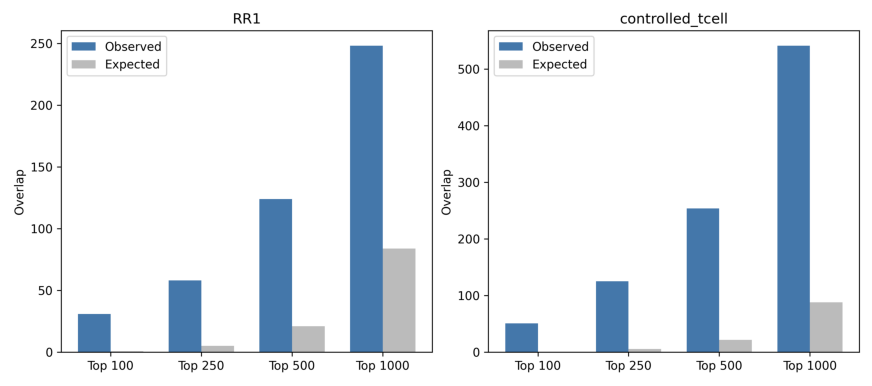

In [37]:
conv_dir=profiler_dir/'conventional_expression_baseline'
conv_summary=read_json(conv_dir/'final_summary.json')
display(pd.DataFrame([conv_summary]).style.format(precision=3).hide(axis='index'))
display(read_csv(conv_dir/'analysis_summary.csv').style.hide(axis='index'))
for name in ['pathway_family_comparison.png','gene_ranking_concordance.png','gene_topn_overlap.png']:
    img=plt.imread(conv_dir/'figures'/name);plt.figure(figsize=(11,6));plt.imshow(img);plt.axis('off');plt.show()

#### Are context-sensitive genes simply the most differentially affected genes?

Not entirely. Controlled T-cell conventional and contextual rankings correlate substantially (**Spearman 0.581**) and share 51/100, 254/500, and 541/1000 leading genes, so BridgeRNA largely preserves the strong controlled expression effect. In RR1, genome-wide correlation is only **0.075**, despite significant concentration at the top (31/100, 124/500, and 248/1000). Thus RR1 contextualization selects many conventionally unstable genes but substantially reorganizes their broader ordering.

At a 10% rank threshold, T cells contain 522 genes with weak conventional but strong contextual change; RR1 contains **902**. The same qualitative result persists at 5% and 20%, so Category C is not created by one arbitrary cutoff.

In [38]:
display(read_csv(conv_dir/'conventional_vs_contextual_rank_correlations.csv').style.format(precision=3).hide(axis='index'))
display(read_csv(conv_dir/'conventional_vs_contextual_topn_overlap.csv').style.format({'expected':'{:.1f}','fold_enrichment':'{:.2f}','hypergeom_p':'{:.2e}'}).hide(axis='index'))
categories=read_csv(conv_dir/'expression_context_gene_categories.csv')
display(categories.drop(columns='gene_symbols').style.hide(axis='index'))
for analysis in ['controlled_tcell','RR1']:
    genes_row=categories.query("analysis == @analysis and top_fraction == 0.10 and category == 'weak_expression_strong_context'").iloc[0]
    print(f"{analysis} — example weak-expression/strong-context genes:", ', '.join(str(genes_row.gene_symbols).split(';')[:25]))

analysis,genes,spearman
controlled_tcell,11373,0.581
RR1,11916,0.075


analysis,top_n,overlap,expected,fold_enrichment,hypergeom_p
controlled_tcell,100,51,0.9,58.00,1.95e-83
controlled_tcell,250,125,5.5,22.75,7.99e-151
controlled_tcell,500,254,22.0,11.55,6.82e-232
controlled_tcell,1000,541,87.9,6.15,0.00e+00
RR1,100,31,0.8,36.94,1.11e-41
RR1,250,58,5.2,11.06,6.99e-45
RR1,500,124,21.0,5.91,1.50e-63
RR1,1000,248,83.9,2.96,1.01e-61


analysis,top_fraction,category,genes
controlled_tcell,0.050000,strong_expression_and_context,294
controlled_tcell,0.050000,strong_expression_weak_context,274
controlled_tcell,0.050000,weak_expression_strong_context,274
controlled_tcell,0.100000,strong_expression_and_context,615
controlled_tcell,0.100000,strong_expression_weak_context,522
controlled_tcell,0.100000,weak_expression_strong_context,522
controlled_tcell,0.200000,strong_expression_and_context,1362
controlled_tcell,0.200000,strong_expression_weak_context,912
controlled_tcell,0.200000,weak_expression_strong_context,912
RR1,0.050000,strong_expression_and_context,146


controlled_tcell — example weak-expression/strong-context genes: ABTB2, ACTR3, ADAD2, ADAMTSL4, ADORA2B, AFF2, AHR, AKR1E2, ALOX12, AMDHD2, AMH, ANKRD37, ANKRD61, ANXA9, AOPEP, AP3B1, APOBEC2, AQP11, ARFRP1, ARG1, ARHGAP44, ARMH2, ARMH4, ARRDC5, ASCL5
RR1 — example weak-expression/strong-context genes: ABCA7, ABHD1, ABI1, ABL1, ABRAXAS1, ACAP1, ACKR1, ACTR3, ACVR1, ADAM10, ADO, ADPGK, AEBP2, AFTPH, AGRN, AKAP8, AKIRIN1, ALG6, AMPD2, ANGEL2, ANKHD1, ANKIB1, ANKMY2, ANKRA2, ANKRD11


#### Pathway-family comparison

Conventional T-cell DE detects all three predefined families. Conventional RR1 interaction analysis detects RNA processing/splicing, but **not** chromatin or DNA repair at FDR < 0.05. Consequently, conventional expression reproduces only **1/3** cross-context pathway families and shares no exact significant pathway between T cells and RR1. BridgeRNA contextual analysis reproduces **3/3**, shares nine exact significant pathways, and has a positive cross-context absolute-NES correlation (0.166 versus −0.085 conventionally).

Leading-edge results sharpen this distinction. In controlled T cells, conventional and contextual leading edges strongly overlap for all three families. In RR1, RNA-processing leading edges overlap 40 genes, whereas chromatin and DNA repair have no conventional significant leading edge to compare. BridgeRNA therefore does not invent the controlled effect, but its RR1 contextual representation exposes coherent chromatin/DNA-repair organization not recovered by the standard interaction ranking.

In [39]:
display(read_csv(conv_dir/'pathway_family_concordance.csv').style.format(precision=3,na_rep='—').hide(axis='index'))
display(read_csv(conv_dir/'cross_context_pathway_agreement.csv').style.format(precision=3).hide(axis='index'))
le=read_csv(conv_dir/'representative_leading_edge_comparison.csv')
display(le.drop(columns='overlap_genes').style.format({'expected_overlap':'{:.2f}','hypergeom_p':'{:.2e}'}).hide(axis='index'))

family,analysis,significant_terms,best_abs_nes,best_fdr,supported
RNA processing / splicing,tcell_conventional,1,2.010,0.017,True
RNA processing / splicing,tcell_bridge_context,2,3.017,0.001,True
RNA processing / splicing,rr1_conventional_instability,3,2.071,0.001,True
RNA processing / splicing,rr1_bridge_context,78,4.878,0.001,True
Chromatin organization / remodeling,tcell_conventional,1,2.013,0.034,True
Chromatin organization / remodeling,tcell_bridge_context,1,2.664,0.001,True
Chromatin organization / remodeling,rr1_conventional_instability,0,—,—,False
Chromatin organization / remodeling,rr1_bridge_context,15,3.973,0.001,True
DNA repair / DNA metabolism,tcell_conventional,1,2.402,0.001,True
DNA repair / DNA metabolism,tcell_bridge_context,1,2.386,0.004,True


analysis,shared_tested_pathways,abs_nes_spearman,significant_pathway_overlap
conventional,4377,-0.085,0
Bridge_contextual,5165,0.166,9


comparison,family,conventional_leading_edge_genes,contextual_leading_edge_genes,overlap,expected_overlap,hypergeom_p
controlled_tcell,RNA processing / splicing,12,12,12,0.01,1.03e-40
RR1,RNA processing / splicing,44,52,40,0.19,2.19e-99
controlled_tcell,Chromatin organization / remodeling,4,5,4,0.00,7.18e-15
RR1,Chromatin organization / remodeling,0,139,0,0.00,nan
controlled_tcell,DNA repair / DNA metabolism,16,7,6,0.01,1.87e-17
RR1,DNA repair / DNA metabolism,0,79,0,0.00,nan


#### Conventional-baseline decision

1. **Are BridgeRNA genes simply the most DE genes?** Partly in the controlled experiment, but not in RR1. RR1 has weak global rank agreement and hundreds of strong-context genes outside the equivalently sized conventional top set.
2. **Does conventional T-cell PolyA/Ribo DE identify the three families?** Yes: RNA processing, chromatin, and DNA repair all appear.
3. **Does conventional RR1 response instability identify them?** Only RNA processing/splicing; chromatin and DNA repair do not reach pathway significance.
4. **Does conventional analysis reproduce T-cell→NASA convergence?** Partially—1/3 predefined families, compared with 3/3 contextually.
5. **Are there low-expression-change/high-context-change genes?** Yes, robustly across 5%, 10%, and 20% rank thresholds.
6. **Does BridgeRNA add information?** It adds organized contextual structure in RR1, but that structure is rooted in and overlaps conventional expression effects. It is not wholly independent information.
7. **Classification:** **AMPLIFICATION/REORGANIZATION OF CONVENTIONAL SIGNAL.** This is stronger than simple preservation, but the evidence does not justify claiming a completely novel latent biological signal unavailable to conventional analysis.

This baseline reinforces the paper-safe Task 4 conclusion: BridgeRNA contextualization organizes technical-associated expression changes into cross-context pathway structure, particularly chromatin and DNA-repair families in RR1, while retaining substantial conventional signal. It does not prove causal regulation, pathway activation, or exclusive PolyA/Ribo causality.

### Expression-Adjusted Contextual Sensitivity

This final gene-level control asks whether context changes more than expected given conventional expression behavior. It does not remove Top-N DE genes. Each experiment is modeled independently with robust LOWESS (`frac=0.20`, three robustifying iterations):

- Predictor: `log1p(sqrt(edgeR QL F))`, a continuous conventional-effect magnitude.
- Controlled T-cell outcome: `log1p(contextual sensitivity score)`.
- RR1 outcome: normalized contextual discrepancy.
- Expression-adjusted contextual sensitivity: observed outcome minus LOWESS prediction. Positive values indicate more contextual change than expected from conventional behavior.
- Sensitivity analysis: LOWESS on within-experiment percentile ranks.

Only genes valid in both analyses are used: **11,373 controlled T-cell genes** and **11,916 RR1 genes**.

tcell_genes,rr1_genes,tcell_expression_context_spearman,rr1_expression_context_spearman,cross_context_residual_spearman,shared_retained_pathway_families,classification,lowess,rank_sensitivity,permutation_control,elapsed_minutes
11373,11916,0.5806,0.0752,0.0051,['RNA processing / splicing'],PARTIAL ADDITIONAL CONTEXTUAL ORGANIZATION,"robust LOWESS frac=0.20, it=3 on log1p conventional statistic; log1p contextual score for T cells and normalized discrepancy for RR1",LOWESS on within-experiment percentile ranks,"1,000 independent gene-label shuffles; joint family mean percentile competitive statistic",3.9509


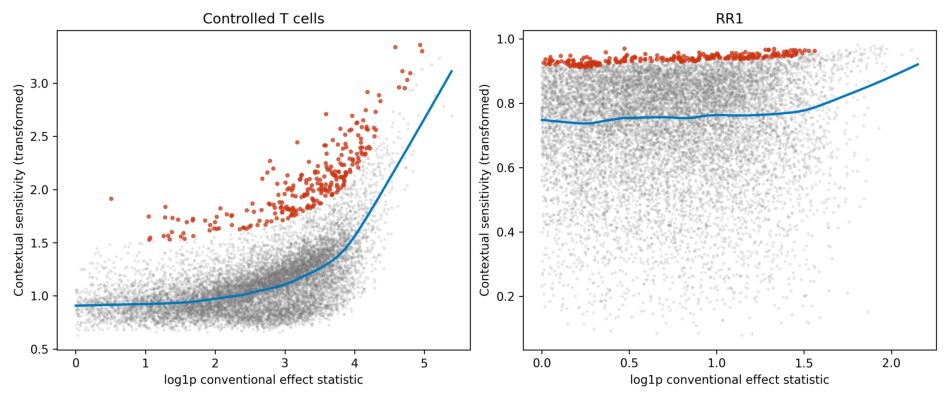

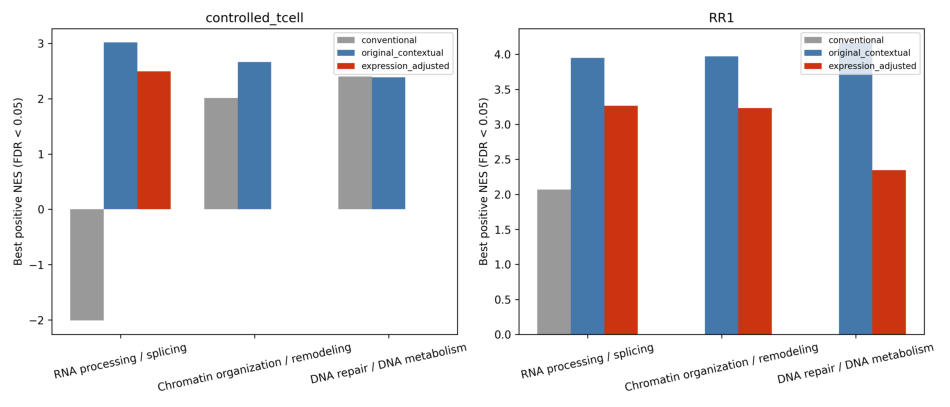

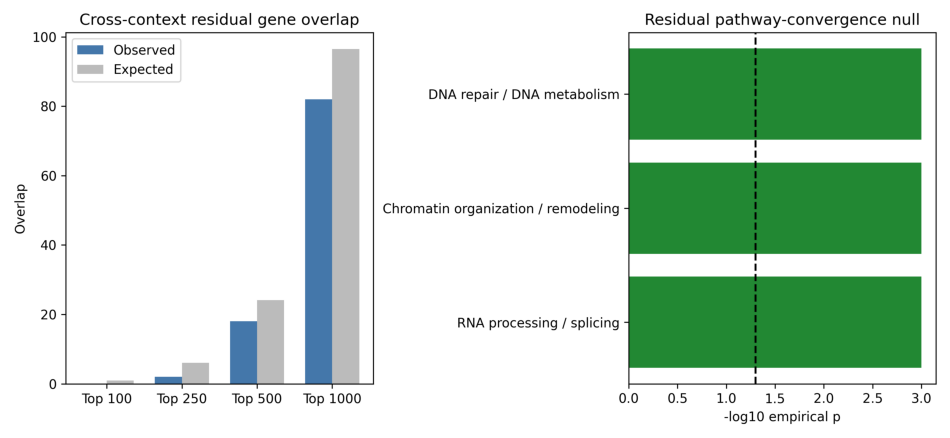

In [40]:
adjusted_dir=profiler_dir/'expression_adjusted_context'
adjusted_summary=read_json(adjusted_dir/'final_summary.json')
display(pd.DataFrame([adjusted_summary]).style.format(precision=4).hide(axis='index'))
for name in ['expression_vs_contextual_sensitivity.png','residual_pathway_family_comparison.png','cross_context_residual_concordance.png']:
    img=plt.imread(adjusted_dir/'figures'/name);plt.figure(figsize=(12,6));plt.imshow(img);plt.axis('off');plt.show()

#### Residual validity and context-excess genes

Residuals are effectively uncorrelated with their fitted expression statistic (T cells **0.011**, RR1 **−0.003**) and are not dominated by low-expression genes. Only 1–2% of the RR1 positive residual tail lies in the lowest expression decile; 0.4–5.1% lies in the lowest contextual-magnitude decile. Re-fitting after jointly excluding the lowest 5%, 10%, or 20% by expression and contextual magnitude preserves residual rankings strongly (Spearman 0.982–1.000).

The controlled residual remains correlated with contextual displacement magnitude (0.763), as expected for a response whose definition explicitly contains magnitude. RR1 residual is inversely correlated with contextual-response magnitude (−0.550), but the positive tail is not dominated by low-magnitude genes. These residuals isolate excess relative to conventional effects; they do not eliminate all dependence on the contextual metric's own construction.

In [41]:
audit=read_csv(adjusted_dir/'residual_artifact_audit.csv')
display(audit.style.format(precision=3).hide(axis='index'))
cats=read_csv(adjusted_dir/'context_categories.csv')
display(cats.drop(columns='gene_symbols').style.hide(axis='index'))
for analysis in ['controlled_tcell','RR1']:
    q=read_csv(adjusted_dir/f'{analysis}_context_excess_ranking.csv')
    display(Markdown(f'**{analysis}: Top 25 context-excess genes**'))
    keep=[c for c in ['gene_symbol','expression_statistic','logFC','FDR','contextual_statistic','predicted_contextual_sensitivity','residual_contextual_sensitivity','standardized_residual','expression_abundance'] if c in q]
    display(q[keep].head(25).style.format(precision=3).hide(axis='index'))

analysis,audit,excluded_fraction,genes,spearman,top500_overlap
controlled_tcell,residual_vs_expression_statistic,0.000,11373,0.011,500.000
controlled_tcell,residual_vs_expression_abundance,0.000,11373,-0.183,500.000
controlled_tcell,residual_vs_contextual_displacement_magnitude,0.000,11373,0.763,500.000
controlled_tcell,refit_after_expression_and_magnitude_filter,0.050,10258,0.999,478.000
controlled_tcell,refit_after_expression_and_magnitude_filter,0.100,9171,0.998,410.000
controlled_tcell,refit_after_expression_and_magnitude_filter,0.200,7115,0.982,226.000
controlled_tcell,positive_tail_low_feature_prevalence,100.000,100,0.170,0.000
controlled_tcell,positive_tail_low_feature_prevalence,250.000,250,0.144,0.000
controlled_tcell,positive_tail_low_feature_prevalence,500.000,500,0.180,0.000
controlled_tcell,positive_tail_low_feature_prevalence,1000.000,1000,0.189,0.000


analysis,top_fraction,category,genes
controlled_tcell,0.050000,strong_expression_strong_context,294
controlled_tcell,0.050000,strong_expression_weak_context,274
controlled_tcell,0.050000,weak_expression_strong_context,274
controlled_tcell,0.050000,weak_expression_weak_context,10531
controlled_tcell,0.100000,strong_expression_strong_context,615
controlled_tcell,0.100000,strong_expression_weak_context,522
controlled_tcell,0.100000,weak_expression_strong_context,522
controlled_tcell,0.100000,weak_expression_weak_context,9714
controlled_tcell,0.200000,strong_expression_strong_context,1362
controlled_tcell,0.200000,strong_expression_weak_context,912


**controlled_tcell: Top 25 context-excess genes**

gene_symbol,expression_statistic,logFC,FDR,contextual_statistic,predicted_contextual_sensitivity,residual_contextual_sensitivity,standardized_residual,expression_abundance
CIBAR1,35.135,-4.574,0.000,14.029,1.291,1.419,6.177,1.423
H1-1,22.906,6.523,0.000,10.535,1.155,1.291,5.613,0.664
TAS2R41,15.207,2.322,0.000,8.682,1.069,1.201,5.216,0.969
MT-ATP6,43.399,-5.066,0.000,12.109,1.393,1.180,5.124,7.935
CXCR5,64.551,-5.409,0.000,17.498,1.749,1.169,5.075,3.142
WDR74,51.679,6.251,0.000,13.818,1.528,1.168,5.072,6.963
JSRP1,96.750,-6.984,0.000,27.248,2.193,1.148,4.985,2.333
WIPI1,34.307,-3.111,0.000,10.206,1.282,1.135,4.925,2.042
TMEM255A,38.907,-5.612,0.000,10.794,1.336,1.132,4.912,0.698
SLC3A1,34.950,-2.876,0.000,10.195,1.289,1.126,4.889,1.343


**RR1: Top 25 context-excess genes**

gene_symbol,expression_statistic,logFC,FDR,contextual_statistic,predicted_contextual_sensitivity,residual_contextual_sensitivity,standardized_residual,expression_abundance
UBE2V1,0.603,-0.248,0.788,0.971,0.754,0.216,1.463,3.540
RNPS1,0.441,-0.065,0.854,0.959,0.746,0.213,1.443,3.204
UBP1,0.177,-0.018,0.945,0.949,0.740,0.209,1.418,3.372
RBM22,0.294,0.033,0.906,0.944,0.737,0.207,1.403,3.056
ANKRD17,0.272,-0.030,0.913,0.943,0.737,0.205,1.396,2.897
ANKRD11,0.113,0.013,0.970,0.948,0.743,0.205,1.395,3.050
HSD17B1,2.774,-1.548,0.108,0.969,0.766,0.203,1.383,0.488
BRD1,1.180,-0.159,0.545,0.957,0.754,0.203,1.381,2.475
UBAP1L,2.591,-1.711,0.134,0.967,0.765,0.202,1.375,0.376
ZNF207,2.659,-0.267,0.123,0.967,0.765,0.201,1.373,3.679


#### Residual pathway results

Residual GSEA uses the same 15,165-gene-compatible tested universes, GO BP/KEGG/Reactome files, 10–500 gene-set limits, and 1,000 permutations. It is run for both raw LOWESS residuals and rank residuals.

- **Controlled T cells:** RNA processing/splicing is partially retained. Chromatin and DNA repair no longer reach residual-GSEA significance and are classified as explained by conventional expression in this context.
- **RR1:** RNA processing, chromatin, and DNA repair are strongly retained under both residual definitions. Thus, RR1's chromatin/DNA-repair contextual organization is not a simple monotonic restatement of its edgeR interaction statistic.
- **Strict cross-context conclusion:** only RNA processing survives expression adjustment in both experiments. It is driven by different genes: the representative residual leading edges share zero genes.

The 1,000-shuffle competitive family control places the observed joint mean residual percentile above all permutations for each broad family (`p=0.001`). However, because T-cell chromatin and DNA-repair fail the stricter residual GSEA criterion, those two are not claimed as robust residual cross-context convergence.

In [42]:
display(read_csv(adjusted_dir/'pathway_family_comparison.csv').style.format(precision=3,na_rep='—').hide(axis='index'))
display(read_csv(adjusted_dir/'pathway_family_decisions.csv').style.hide(axis='index'))
display(read_csv(adjusted_dir/'permutation_pathway_control.csv').style.format(precision=4).hide(axis='index'))
display(read_csv(adjusted_dir/'residual_leading_edge_comparison.csv').drop(columns='overlap_genes').style.format({'expected':'{:.2f}','hypergeom_p':'{:.3g}'}).hide(axis='index'))

experiment,family,signal,significant_terms,best_positive_nes,best_abs_nes,best_fdr
controlled_tcell,RNA processing / splicing,conventional,1,-2.010,2.010,0.017
controlled_tcell,RNA processing / splicing,original_contextual,2,3.017,3.017,0.001
controlled_tcell,RNA processing / splicing,expression_adjusted,2,2.493,2.493,0.001
controlled_tcell,Chromatin organization / remodeling,conventional,1,2.013,2.013,0.034
controlled_tcell,Chromatin organization / remodeling,original_contextual,1,2.664,2.664,0.001
controlled_tcell,Chromatin organization / remodeling,expression_adjusted,0,—,—,—
controlled_tcell,DNA repair / DNA metabolism,conventional,1,2.402,2.402,0.001
controlled_tcell,DNA repair / DNA metabolism,original_contextual,1,2.386,2.386,0.004
controlled_tcell,DNA repair / DNA metabolism,expression_adjusted,0,—,—,—
RR1,RNA processing / splicing,conventional,3,2.071,2.071,0.001


experiment,family,classification
controlled_tcell,RNA processing / splicing,PARTIALLY RETAINED AFTER EXPRESSION ADJUSTMENT
RR1,RNA processing / splicing,STRONGLY RETAINED AFTER EXPRESSION ADJUSTMENT
controlled_tcell,Chromatin organization / remodeling,EXPLAINED BY CONVENTIONAL EXPRESSION
RR1,Chromatin organization / remodeling,STRONGLY RETAINED AFTER EXPRESSION ADJUSTMENT
controlled_tcell,DNA repair / DNA metabolism,EXPLAINED BY CONVENTIONAL EXPRESSION
RR1,DNA repair / DNA metabolism,STRONGLY RETAINED AFTER EXPRESSION ADJUSTMENT


family,observed_joint_mean_percentile,null_mean,null_sd,empirical_p
RNA processing / splicing,0.5602,0.5002,0.0057,0.0010
Chromatin organization / remodeling,0.5689,0.5003,0.0079,0.0010
DNA repair / DNA metabolism,0.5344,0.5002,0.0078,0.0010


family,tcell_leading_edge,rr1_leading_edge,overlap,expected,hypergeom_p
RNA processing / splicing,11,145,0,0.15,1
Chromatin organization / remodeling,0,132,0,0.00,nan
DNA repair / DNA metabolism,0,77,0,0.00,nan


#### Cross-context residual gene test

Expression adjustment removes gene-level cross-context concordance: residual T-cell and RR1 rankings have Spearman **0.005**. Top-100 overlap is zero; Top-250/500/1000 overlaps are at or below random expectation and nonsignificant. Therefore, any residual shared functional organization is unequivocally **same broad program, different genes**, not a conserved individual-gene signature.

In [43]:
display(read_csv(adjusted_dir/'cross_context_gene_overlap.csv').drop(columns='genes').style.format({'expected':'{:.2f}','fold_enrichment':'{:.2f}','hypergeom_p':'{:.3g}'}).hide(axis='index'))

top_n,overlap,expected,fold_enrichment,hypergeom_p
100,0,0.96,0.00,1
250,2,6.03,0.33,0.985
500,18,24.11,0.75,0.926
1000,82,96.44,0.85,0.956


#### Final expression-adjusted decision

1. Conventional effects explain a substantial fraction of controlled T-cell contextual ranking structure (unadjusted Spearman 0.581) but little of RR1's genome-wide contextual ordering (0.075).
2. Large, stable residual contextual signals remain after nonlinear and rank-based adjustment, without low-expression or near-zero-context domination.
3. RR1 context-excess genes form coherent RNA-processing, chromatin, and DNA-repair programs.
4. Strict T-cell→liver residual convergence remains only for RNA processing/splicing.
5. Residual RNA-processing leading edges contain different genes in the two contexts.
6. Chromatin and DNA repair remain RR1-specific residual contextual organization, not independently reproduced residual families in controlled T cells.
7. **Classification: PARTIAL ADDITIONAL CONTEXTUAL ORGANIZATION.** BridgeRNA encodes functional gene-context organization beyond what the conventional per-gene statistic predicts, especially within RR1, but the strongest three-family cross-context result is partly explained by conventional expression. It is neither wholly novel nor merely a nonlinear restatement of DE.

This is the final planned Task 4 gene-level control. No causal gene, dedicated pathway dimension, pathway activation, purified biology, or universal technical reference is inferred.

### Concise comparison and interpretation

### Concise comparison and interpretation

1. **Expected behavior is reproduced.** RR1 is opposing (`R = −0.804`) and strongly aligned with PC1–2 (`T = 0.953`); RR3-39 is moderately reproducible (`R = 0.790`) with lower alignment (`T = 0.141`); RR3-40 is highly reproducible (`R = 0.917`) despite appreciable alignment (`T = 0.466`).
2. **R and T are distinct.** RR3-40 demonstrates that technical-associated structure can be detectable in the comparatively small discrepancy while the primary FLT−GC response remains reproducible.
3. **RR1 is unusually aligned.** Its score is above all 1,000 random two-dimensional subspaces (`p = 0.001`) and stable across donor bootstraps (median 0.948; 95% interval 0.925–0.958).
4. **Biological overlap matters.** Stronger removal resolves RR1 only while disrupting broader response organization; technical-associated and biological structure are not cleanly separable.
5. **Attribution adds impact context.** RR1 shows gene reweighting within hepatic metabolic programs, while RR3 has greater attribution concordance and Top-100 overlap.
6. **Contextual relationships also change.** RR1 has median gene-context reproducibility −0.125 with 61.6% reversed gene-context responses, compared with medians 0.783/0.864 and reversal fractions 7.5%/6.6% for RR3-39/RR3-40. The most contextually unstable RR1 genes show RNA-processing, chromatin, and DNA-repair enrichment; they overlap little with Top-100 IG genes, indicating complementary information.
7. **The assumption remains explicit.** The reference is stable within controlled T cells, but its cross-tissue universality is unknown.

**RR1 overall:** The RR1 mouse-liver spaceflight response reverses across remeasurement (`R = −0.804`). Its discrepancy is strongly aligned with the controlled PolyA/Ribo reference (`T = 0.953`). Removing sufficient technical-associated structure to resolve this reversal preserves only 0.559 correlation with the broader response-similarity organization. Gene attribution shows response-basis reweighting, while contextual analysis shows widespread instability in genes' learned transcriptomic relationships. The associated latent structure is therefore technically sensitive and biologically entangled—not proven purely technical, causal, or safely correctable.

## 12. Final benchmark summary

In [44]:
if not summary.empty:
    final = summary.rename(columns={'representation':'Representation','auroc':'PolyA/Ribo AUROC','pair_cosine':'Pair cosine','pair_r1':'Pair R@1'})
    if not task3.empty:
        challenge = task3.pivot(index='representation',columns='comparison',values='cosine').reset_index().rename(columns={'representation':'Representation'})
        final = final.merge(challenge, on='Representation', how='left')
    final = final.rename(columns={'biology_metric_value':'Biology metric (source-ID MRR)'})
    keep = [c for c in ['Representation','PolyA/Ribo AUROC','Pair cosine','Pair R@1','Biology metric (source-ID MRR)','macro_f1','RR1','RR3-39','RR3-40'] if c in final]
    display(final[keep].style.format(precision=3,na_rep='—'))

,Representation,PolyA/Ribo AUROC,Pair cosine,Pair R@1,Biology metric (source-ID MRR),macro_f1,RR1,RR3-39,RR3-40
0,Bridge,0.000,0.882,0.750,0.875,0.200,-0.804,0.790,0.917
1,Linear baseline,0.500,0.883,0.750,0.875,0.333,-0.709,0.724,0.881
2,FE,0.000,0.786,0.500,0.750,0.333,-0.994,0.998,0.995
3,RE,0.000,0.165,0.500,0.750,0.200,-0.902,0.580,0.999
4,FE without_pair,0.000,0.838,0.500,0.750,0.333,—,—,—
5,FE without_adversarial,0.078,0.996,0.500,0.750,0.200,—,—,—
6,FE shuffled_labels,0.000,1.000,0.500,0.750,0.000,—,—,—
7,FE shuffled_pairs,0.000,0.986,0.500,0.750,0.333,—,—,—


## 13. Conservative interpretation

The completed evidence should answer whether original Bridge encodes library information, whether displacement generalizes, whether FE reduces it without erasing biology, whether RE isolates it, whether the decomposition generalizes, and whether RR1 improves without damaging RR3.

Until several independent authoritative same-RNA studies are available, generalization and causal attribution remain provisional. The current external test contains only two biological source RNAs, so effect sizes and failures matter more than nominal significance.

In [45]:
if not summary.empty and not task3.empty:
    s = summary.set_index('representation')
    t = task3.pivot(index='representation',columns='comparison',values='cosine')
    print(f"Held-out Bridge AUROC: {s.loc['Bridge','auroc']:.3f}; FE AUROC: {s.loc['FE','auroc']:.3f}; RE AUROC: {s.loc['RE','auroc']:.3f}")
    print(f"Pair cosine Bridge→FE: {s.loc['Bridge','pair_cosine']:.3f} → {s.loc['FE','pair_cosine']:.3f}")
    print(f"Pair R@1 Bridge→FE: {s.loc['Bridge','pair_r1']:.3f} → {s.loc['FE','pair_r1']:.3f}")
    print(f"RR1 cosine Bridge→FE: {t.loc['Bridge','RR1']:.3f} → {t.loc['FE','RR1']:.3f}")
    print('Conclusion: this exploratory FE/RE fit does not meet the predefined success criteria. It neither improves held-out pair correspondence nor remedies RR1. The result cannot specifically implicate PolyA/Ribo; the RR1 reversal remains attributable to a broader protocol transition.')

Held-out Bridge AUROC: 0.000; FE AUROC: 0.000; RE AUROC: 0.000
Pair cosine Bridge→FE: 0.882 → 0.786
Pair R@1 Bridge→FE: 0.750 → 0.500
RR1 cosine Bridge→FE: -0.804 → -0.994
Conclusion: this exploratory FE/RE fit does not meet the predefined success criteria. It neither improves held-out pair correspondence nor remedies RR1. The result cannot specifically implicate PolyA/Ribo; the RR1 reversal remains attributable to a broader protocol transition.
